# MEASURING HATE SPEECH

## 1. Introduzione

## 2. Setup & EDA 

### 2.0. - Setup

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

REPO_NAME = "measuring-hate-speech-audit"
REPO_URL  = "https://github.com/AndreaMorbello/measuring-hate-speech-audit.git"
MARKER    = Path("src") / "data.py"

def _find_repo_root() -> Path:
    for d in [Path.cwd(), *Path.cwd().parents]:
        if (d / MARKER).exists():
            return d
    raise RuntimeError(f"Repo root non trovato: nessun '{MARKER}' nelle dir parent.")

if IN_COLAB:
    if not Path(REPO_NAME).exists():
        !git clone {REPO_URL}
    REPO_ROOT = Path(REPO_NAME).resolve()
else:
    REPO_ROOT = _find_repo_root()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Ambiente: {'Colab' if IN_COLAB else 'Locale'}")
print(f"Repo root: {REPO_ROOT}")


Ambiente: Locale
Repo root: c:\Users\LENOVO\Documents\dev\measuring-hate-speech-audit


### 2.1. - Importazione librerie e setup generale


Oltre agli import fondamentali, vengono inizializzate le costanti che saranno utili per l'importazione del dataset e per l'Explorative Data Analysis.

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import (
    get_column_groups,
    summarize_dataset,
    HF_DATASET_NAME,
    HF_CONFIG,
    platform_distribution,
    label_correlation_matrix,
    annotator_productivity,
    build_annotators_df,
    build_comments_df,
)

FIGURES_DIR = REPO_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

c:\Users\LENOVO\Documents\dev\measuring-hate-speech-audit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.2. Caricamento del dataset

Caricamento del dataset come DataFrame e creazione di una copia da mantenersi RAW.

In [3]:
df: pd.DataFrame = load_dataset(HF_DATASET_NAME, HF_CONFIG)["train"].to_pandas()
df_raw: pd.DataFrame = df.copy()

df.head(5)

,comment_id,annotator_id,platform,sentiment,respect,insult,humiliate,status,dehumanize,violence,...,annotator_religion_hindu,annotator_religion_jewish,annotator_religion_mormon,annotator_religion_muslim,annotator_religion_nothing,annotator_religion_other,annotator_sexuality_bisexual,annotator_sexuality_gay,annotator_sexuality_straight,annotator_sexuality_other
0,47777,10873,3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,39773,2790,2,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,47101,3379,3,4.0,4.0,4.0,4.0,4.0,4.0,0.0,...,False,False,False,False,True,False,False,False,True,False
3,43625,7365,3,2.0,3.0,2.0,1.0,2.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,12538,488,0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,False,False,False,False,False,False,False,False,True,False


### 2.3. - Categorizzazione delle colonne

Le 143 colonne del dataset non sono epistemologicamente equivalenti: alcune identificano direttamente individui, altre descrivono caratteristiche demografiche degli annotatori, altre ancora qualificano i bersagli del discorso annotato. Un audit etico richiede di esplicitare questa stratificazione prima di qualsiasi analisi.

Seguendo la struttura del paper originale (Kennedy et al. 2020) e le categorie del GDPR, raggruppiamo le colonne in otto classi distinte:

- **Identificatori diretti** (`comment_id`, `annotator_id`): puntano in modo univoco a record e individui.
- **Testo** (`text`): il contenuto annotato, oggetto del compito di classificazione.
- **Metadata** (`platform`): piattaforma di provenienza del commento (Youtube, Reddit, Twitter...).
- **Outcome variables**: dieci etichette ordinali (sentiment, respect, insult, humiliate, status, dehumanize, violence, genocide, attack_defend, hatespeech) più lo score continuo `hate_speech_score`, target del modello in Cap. 5.
- **Annotation quality metrics**: parametri diagnostici del modello psicometrico Rasch usato per costruire `hate_speech_score`, tra cui `annotator_severity` e l'item parameter `hypothesis`.
- **Target groups**: 65 colonne che codificano i gruppi protetti bersaglio del commento (razza, religione, origine, genere, sessualità, età, disabilità, orientamento politico), oggetto dell'analisi di bias del dataset e di fairness del modello.
- **Annotator quasi-identifiers (summary)**: sei colonne categoriche sui demografici degli annotatori (genere, identità trans, istruzione, reddito, ideologia, età). **Sono il materiale operativo del Cap. 3**: l'esercizio di k-anonymity ed l-diversity si applica a queste.
- **Annotator quasi-identifiers (dummies)**: le stesse informazioni demografiche in forma binaria one-hot, utili come feature in fase di modellazione (Cap. 5) ma ridondanti per l'audit privacy.

Questa categorizzazione orienta l'intera pipeline. Ogni capitolo successivo opera su uno o due sottoinsiemi specifici, esplicitando di volta in volta quale gruppo è in gioco e perché.

In [4]:
column_groups: dict = get_column_groups(df)


for group_name, columns in column_groups.items():
    print(f"{group_name:25s}  {len(columns):3d} colonne")

direct_identifiers           2 colonne
text                         1 colonne
metadata                     1 colonne
outcomes                    11 colonne
annotation_quality           7 colonne
target_groups               65 colonne
annotator_qi_summary         6 colonne
annotator_qi_dummies        50 colonne
other                        0 colonne


### 2.4.1. - Statistiche descrittive di base

Prima di qualsiasi analisi mirata, fissiamo le quattro grandezze strutturali del dataset: numero di righe (= annotazioni totali), numero di commenti distinti, numero di annotatori distinti, e la distribuzione delle annotazioni per commento.

Il rapporto annotazioni/commenti è cruciale: ogni commento è giudicato da più persone e l'`hate_speech_score` è una **stima IRT aggregata** di più valutazioni soggettive, non una ground truth. Capire questa ridondanza è precondizione per ogni discussione su affidabilità delle label e fairness del modello.

In [5]:
stats: dict = summarize_dataset(df)

print(f"Righe (annotazioni totali):     {stats['n_rows']:>8,}")
print(f"Colonne:                        {stats['n_columns']:>8,}")
print(f"Commenti unici:                 {stats['n_unique_comments']:>8,}")
print(f"Annotatori unici:               {stats['n_unique_annotators']:>8,}")
print(f"Annotazioni per commento (media):   {stats['annotations_per_comment_mean']:.2f}")
print(f"Annotazioni per commento (mediana): {stats['annotations_per_comment_median']:.2f}")

Righe (annotazioni totali):      135,556
Colonne:                             143
Commenti unici:                   39,565
Annotatori unici:                  7,912
Annotazioni per commento (media):   3.43
Annotazioni per commento (mediana): 2.00


### 2.4.2. - Distribuzione per piattaforma

La colonna `platform` codifica la fonte del commento: YouTube, Reddit, Twitter. Non e' un attributo sensibile ai sensi dell'Art. 9 GDPR ne' un quasi-identificatore degli annotatori; rientra nella categoria dei metadata di contesto.

Cio' non lo rende analiticamente innocuo. Ogni piattaforma applica normative e politiche di moderazione differenti, e attira basi utenti con composizioni demografiche e ideologiche distinte. La piattaforma agisce quindi come **proxy strutturale** di una serie di variabili non osservate: convenzioni espressive, vincoli di lunghezza, attese di anonimato, soglie di tolleranza editoriale.

La distribuzione qui descritta ha valore puramente strutturale: serve a documentare il *frame* del corpus, non a derivarne conclusioni di fairness.

**Hook etico**: `platform` e' un **confounder potenziale** per ogni analisi del §4 che condizioni la performance del modello su un gruppo target. Una disparita' apparente per `target_race_black` potrebbe in realta' riflettere una sovra-rappresentazione di un sottogruppo su una specifica piattaforma, dove le norme del discorso amplificano determinati registri retorici. Il §4 tornera' su questo punto stratificando i confronti.

Output: 

* count -> numero di commenti per piattaforma
* pct   -> percentuale presenza di annotazione da piattaforma (approx. 2 decimali)


             count    pct
Reddit       43227  31.89
YouTube      37164  27.42
Twitter      35027  25.84
unknown (3)  20138  14.86


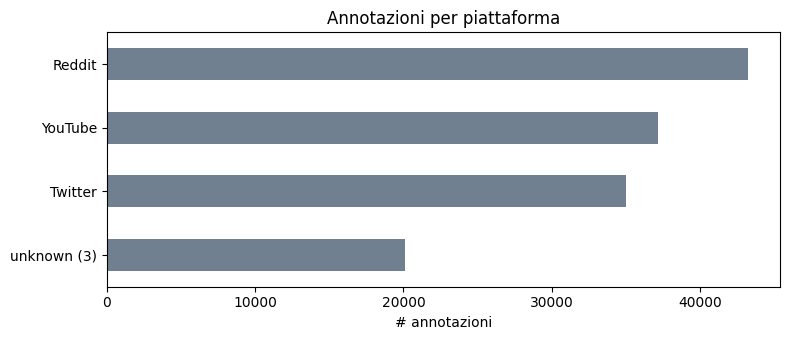

In [6]:
platform_table: pd.DataFrame = platform_distribution(df)
print(platform_table.to_string(float_format=lambda x: f"{x:6.2f}"))

fig, ax = plt.subplots(figsize=(8, 3.5))
platform_table["count"].sort_values().plot(kind="barh", ax=ax, color="slategray")
ax.set_title("Annotazioni per piattaforma")
ax.set_xlabel("# annotazioni")
ax.set_ylabel("")
plt.tight_layout()

fig.savefig(FIGURES_DIR / "eda_platform_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

La distribuzione fra le varie piattaforme non sembra essere eccessivamente sbilanciata. Andrà comunque tenuta in conto la sovra-rappresentazione di comment provenienti da Reddit. (31.89% del totale delle annotazioni)

### 2.5. - Distribuzione dell'outcome continuo

`hate_speech_score` e' la variabile dipendente principale: un punteggio continuo (tipicamente nell'intervallo [-4, +4]) ottenuto via modello Rasch a partire dalle 10 etichette ordinali. Valori positivi crescenti indicano contenuto piu' hateful, valori negativi indicano contenuto sempre piu' supportivo.

**Hook etico**: lo score e' continuo. Qualsiasi classificatore binario (hate / non-hate) richiedera' la scelta di una soglia arbitraria, scelta che influenza direttamente i tassi di falsi positivi e negativi *e che si distribuira' in modo asimmetrico tra i gruppi target* — e' quindi una decisione di fairness, non solo tecnica, che andrà discussa nel §4 e nel §5 durante lo sviluppo del modello.


Statistiche di hate_speech_score:
  mean   -0.5674
  std    +2.3800
  min    -8.3400
  max    +6.3000
  q25    -2.3300
  q75    +1.4100


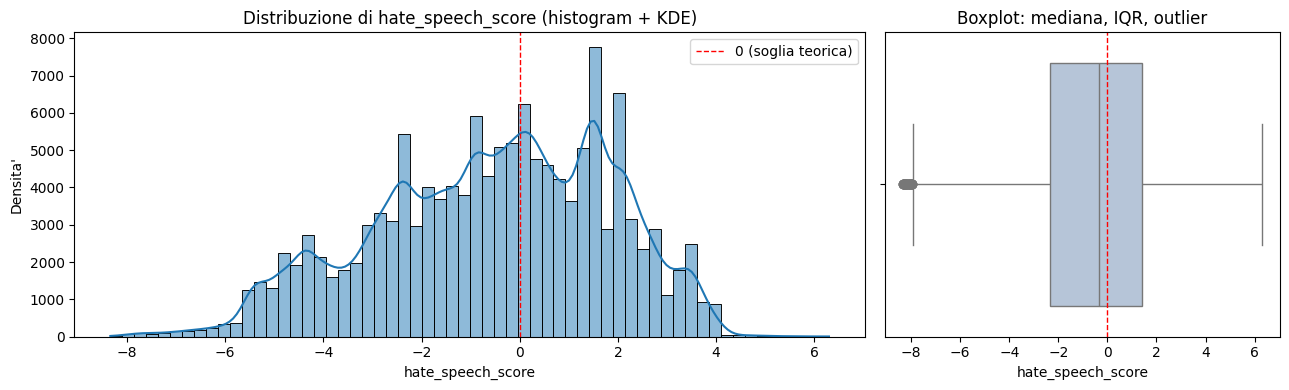

In [7]:
hs_stats: dict = stats["hate_speech_score_stats"]
print("Statistiche di hate_speech_score:")
for k, v in hs_stats.items():
    print(f"  {k:6s} {v:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})

sns.histplot(df["hate_speech_score"], bins=60, kde=True, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--", linewidth=1, label="0 (soglia teorica)")
axes[0].set_title("Distribuzione di hate_speech_score (histogram + KDE)")
axes[0].set_xlabel("hate_speech_score")
axes[0].set_ylabel("Densita'")
axes[0].legend()

sns.boxplot(x=df["hate_speech_score"], ax=axes[1], color="lightsteelblue")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Boxplot: mediana, IQR, outlier")
axes[1].set_xlabel("hate_speech_score")

plt.tight_layout()

fig.savefig(FIGURES_DIR / "eda_hate_speech_score_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

La distribuzione sembra seguire grossomodo una normale con una coda lunga verso il lato dei commenti di supporto.



A complemento delle statistiche aggregate, si riporta anche i **due commenti agli estremi** dello score — il piu' hateful e il piu' supportivo del corpus. L'ispezione qualitativa serve due scopi:

1. Validare che lo score IRT cattura effettivamente cio' che ci aspettiamo (face validity).
2. Rendere visibile la natura concreta del materiale annotato.

In [8]:

unique_comments = df.drop_duplicates(subset="comment_id")[
    ["comment_id", "hate_speech_score", "text"]
]

most_hateful = unique_comments.loc[unique_comments["hate_speech_score"].idxmax()]
most_supportive = unique_comments.loc[unique_comments["hate_speech_score"].idxmin()]

print("\n" + "=" * 70)
print(
    f"COMMENTO PIU' HATEFUL  (score = {most_hateful['hate_speech_score']:+.4f}, "
    f"comment_id = {most_hateful['comment_id']})"
)
print("=" * 70)
print(most_hateful["text"])

print("\n" + "=" * 70)
print(
    f"COMMENTO PIU' SUPPORTIVO  (score = {most_supportive['hate_speech_score']:+.4f}, "
    f"comment_id = {most_supportive['comment_id']})"
)
print("=" * 70)
print(most_supportive["text"])


COMMENTO PIU' HATEFUL  (score = +6.3000, comment_id = 42821)
Dig burn PITS and treat them THE INVADING NAZIS ALL OVER EUROPE. ESPECIALLY THE WOMEN DON'T LET THEM BREED HERE MR. PRESIDENT. FIRING SQUADS SO I CAN VOLUNTEER

COMMENTO PIU' SUPPORTIVO  (score = -8.3400, comment_id = 5360)
Fellow trans girl here! Love and support confirmed!


### 2.6.1. - Distribuzione delle 10 etichette ordinali

Le dieci etichette su scala Likert (0–4) sono le componenti elementari da cui Kennedy et al. derivano `hate_speech_score`. Vederne la distribuzione individualmente serve a:

1. Identificare etichette gravemente sbilanciate (es. `genocide` plausibilmente quasi sempre = 0): qualsiasi modello supervisionato su di esse rischia accuracy alta ma F1 molto bassa per la classe positiva.
2. Capire quali dimensioni di "hatefulness" il dataset misura bene e quali no.

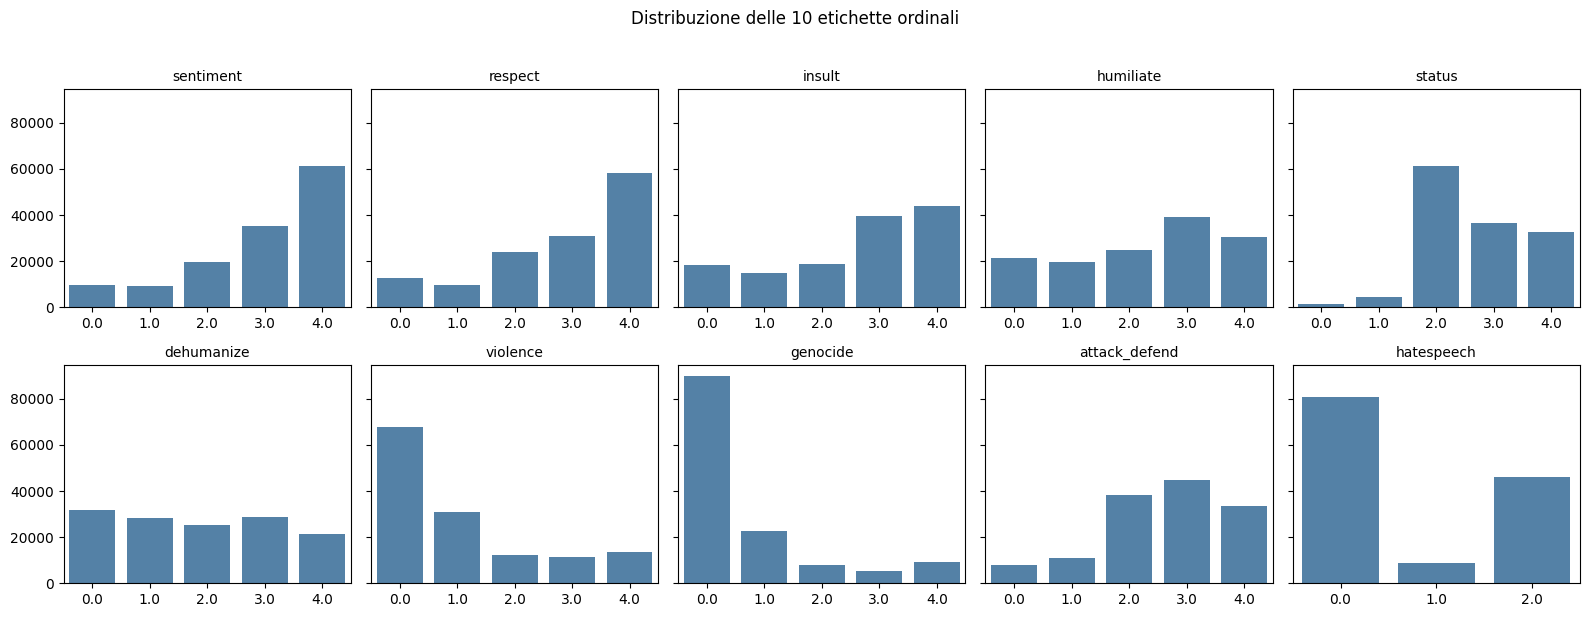

In [9]:
ordinal_labels = [c for c in column_groups["outcomes"] if c != "hate_speech_score"]

fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey=True)
for ax, label in zip(axes.flat, ordinal_labels):
    sns.countplot(x=df[label], ax=ax, color="steelblue")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Distribuzione delle 10 etichette ordinali", y=1.02)
plt.tight_layout()
plt.show()

**Lettura.** `genocide` e `violence` sono quasi sempre = 0 — la classe positiva e' rara al punto da rendere accuracy globale ingannevole. `humiliate`, `status`, `attack_defend` mostrano modi marcati su 0 ma con coda non trascurabile verso 4. Le tre etichette piu' bilanciate sono `sentiment`, `respect` (con la codifica invertita discussa al §2.6.2) e `hatespeech`.

**Implicazione per il §4.4.** Su etichette estremamente sbilanciate, qualunque classificatore tende a predire la classe maggioritaria e raggiungere accuracy ~95% senza catturare casi positivi. Le metriche da usare nell'audit del modello sono F1 della classe hate e AUC-PR, non accuracy globale. Per `genocide` e `violence` il costo asimmetrico e' particolarmente acuto: un falso negativo significa lasciare circolare incitamento alla violenza fisica.

### 2.6.2. - Correlazione tra etichette ordinali
Il modello Rasch usato in Kennedy et al. (2020) per derivare `hate_speech_score` presuppone l'esistenza di un costrutto latente **unidimensionale** che chiamiamo "hatefulness": le dieci etichette sarebbero allora altrettante manifestazioni osservabili dello stesso tratto sottostante. La heatmap di correlazione di Spearman e' lo strumento empirico minimo per stressare questa assunzione.

La scelta di Spearman e non di Pearson e' obbligata: le etichette sono ordinali (scala Likert 0-4), non a intervallo. Spearman misura l'associazione monotonica tra ranghi, senza assumere linearita' ne' distribuzione normale.

Cosa aspettarsi se l'ipotesi di unidimensionalita' regge: blocchi consistenti di correlazioni positive forti tra etichette semanticamente affini (`insult`, `dehumanize`, `humiliate`).
Inoltre, si noti che l'etichetta `respect` indica il grado di 'mancanza di rispetto' del commento, non il contrario. Non sorprende quindi che `respect` sia positivamente correlato con le etichette di hostility

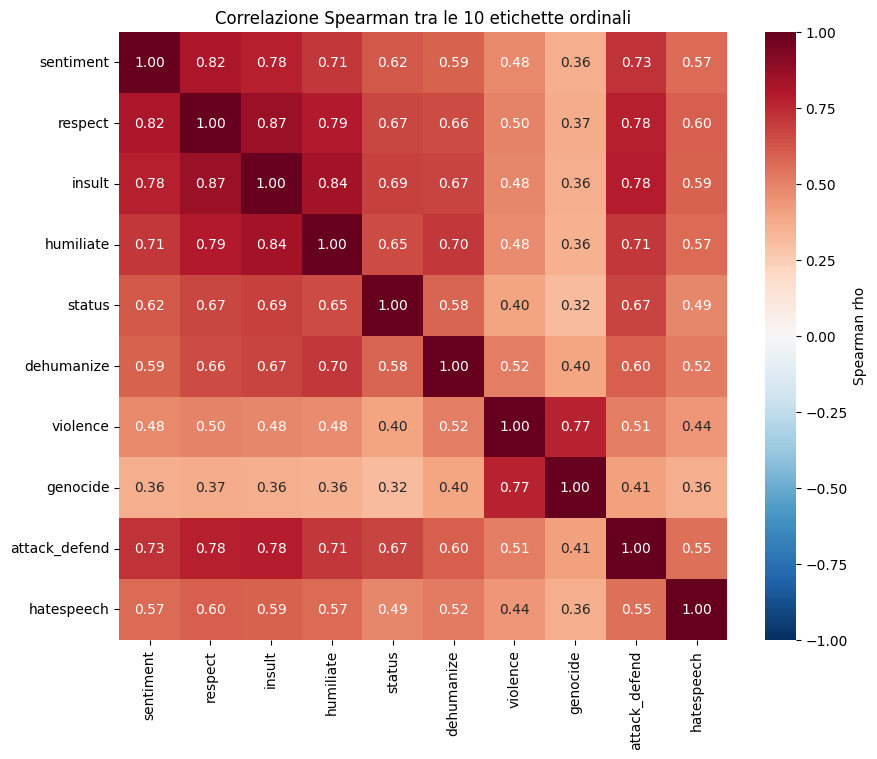

In [10]:
corr_matrix = label_correlation_matrix(df)

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Spearman rho"},
    ax=ax,
)
ax.set_title("Correlazione Spearman tra le 10 etichette ordinali")
plt.tight_layout()

fig.savefig(FIGURES_DIR / "eda_label_correlation_spearman.png", dpi=120, bbox_inches="tight")
plt.show()


Etichette estreme come `genocide` o `violence` mostrano correlazioni basse con il resto, l'aggregazione in un singolo `hate_speech_score` continuo **occulta dimensioni etiche eterogenee**. Un commento marcato come incitamento al genocidio e uno percepito come "insultante ma non violento" possono ricevere punteggi compositi simili pur essendo qualitativamente incomparabili. Il problema diventa centrale al §5: spiegare lo score di un classificatore costruito su un costrutto eterogeneo richiede di esplicitare *quale* dimensione di hatefulness sta guidando la singola predizione, pena un'interpretabilita' falsa.


### 2.7.1. - Demografia degli annotatori

Analizziamo la composizione del pool di annotatori sulle sei dimensioni summary identificate al §2.3: genere, identità trans, istruzione, reddito, ideologia politica, età.

**Attenzione metodologica**: il df è organizzato per annotazione, non per annotatore — un singolo annotatore appare in N righe (una per ciascun commento giudicato). Per la statistica demografica dobbiamo **deduplicare per `annotator_id`**, altrimenti gli annotatori più produttivi pesano sproporzionatamente.

**Hook etico**: questa composizione è la lente attraverso cui il dataset "vede" l'hate speech. Sbilanciamenti sistematici (es. ideologia fortemente polarizzata, sottorappresentazione di gruppi specifici) si traducono in bias delle label che il modello assorbirà silenziosamente. È il punto di partenza obbligato per il §4.

Annotatori unici nel pool: 7,912


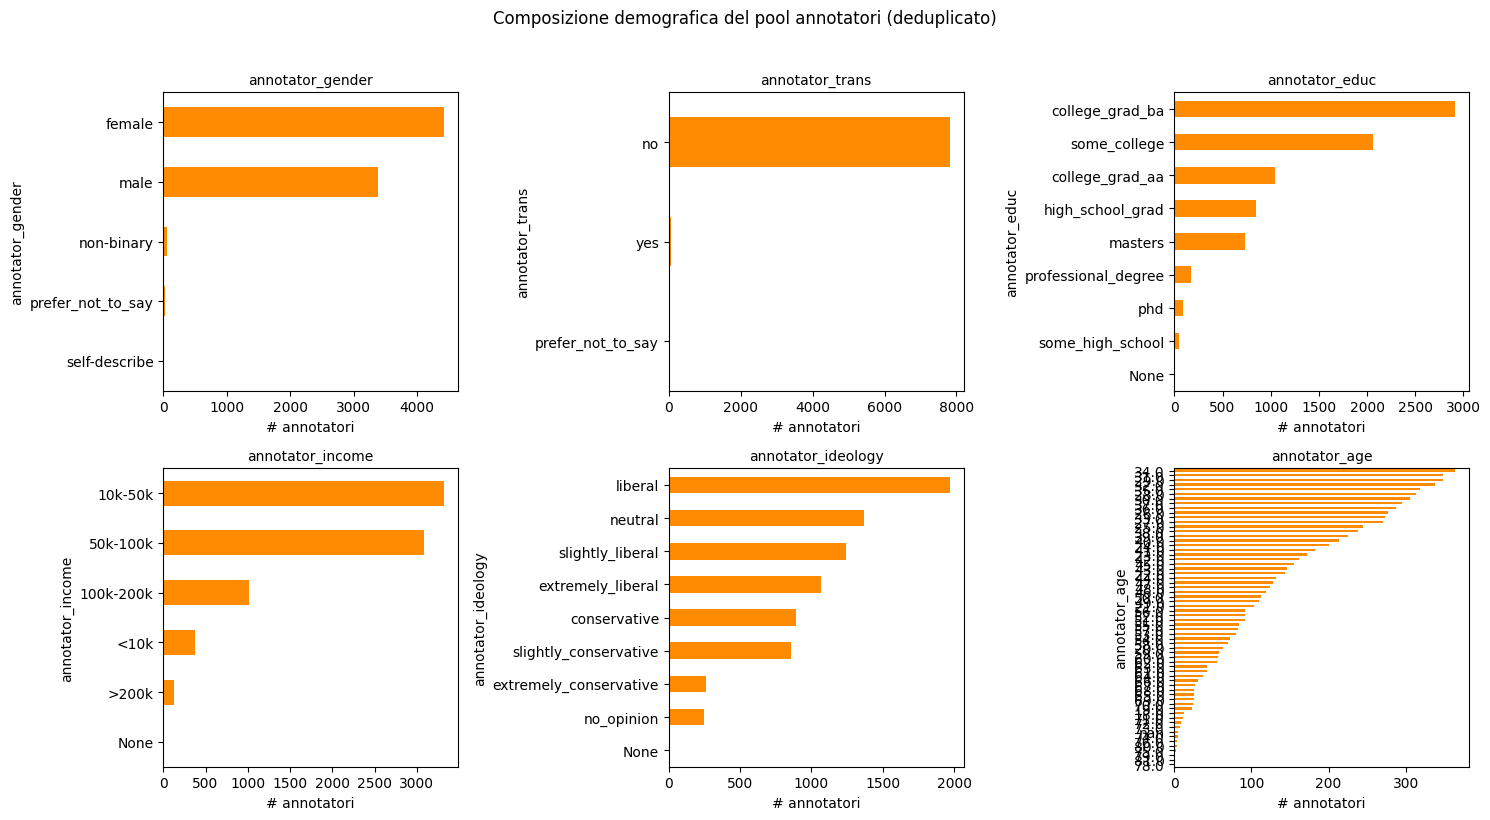

In [11]:
annotators = df.drop_duplicates(subset="annotator_id")
print(f"Annotatori unici nel pool: {len(annotators):,}")

summary_cols = column_groups["annotator_qi_summary"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, summary_cols):
    counts = annotators[col].value_counts(dropna=False)
    counts.plot(kind="barh", ax=ax, color="darkorange")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("# annotatori")
    ax.invert_yaxis()
fig.suptitle("Composizione demografica del pool annotatori (deduplicato)", y=1.02)
plt.tight_layout()
plt.show()

**Lettura della composizione.** Sovra-rappresentati nel pool: `female` (~55%), fascia `30-50`, `some_college` come livello modale di istruzione, `liberal`, race `white` (~74%). Sotto-rappresentati o quasi assenti: `trans=yes` (<1%), `non-binary` e `self-describe` nella categoria genere, `over-65`, redditi estremi (`<10k` e `>200k`), `extremely_conservative`, race minoritarie non-bianche e non-nere. I `NaN` su tutte le QI restano trascurabili (cfr. §2.9).

**Implicazione per il §4.1 (bias di etichetta).** Il modello del §5 ereditera' la posizione di moderazione di questo specifico pool: giovani-adulti bianchi con istruzione media e orientamento liberal, residenti negli USA. Cio' che il dataset chiama "hate speech" e' cio' che questa composizione concorda nel chiamare hate — non un consenso etico universale. Le metriche di fairness del §4.4 misureranno disparita' rispetto a uno standard di severita' costruito da questo gruppo demografico.

### 2.7.2. - Produttività degli annotatori

**Distribuzione della produttivita' tra annotatori**

*Concentrazione della produttivita'*. Il pool annotatori non e' omogeneo per impegno. Mostriamo l'istogramma del numero di annotazioni per persona e calcoliamo l'indice di Gini sulla distribuzione (implementazione manuale, formula chiusa). Un Gini vicino a 0 segnala carico uniforme; valori oltre 0.5 indicano una minoranza produttiva che produce la maggior parte delle etichette.

**Hook etico**: il grafico mette in discussione l'idea stessa di "consenso del pool". Se l'1% piu' produttivo degli annotatori produce una quota sproporzionata di etichette, il modello del §5 imparera' a riprodurre il consenso di una minoranza, non del pool dichiarato.


Annotazioni per annotatore  --  media: 17.13, mediana: 17.00, max: 26
Indice di Gini: 0.1265
Quota di annotazioni prodotta dall'1% piu' produttivo: 1.5%


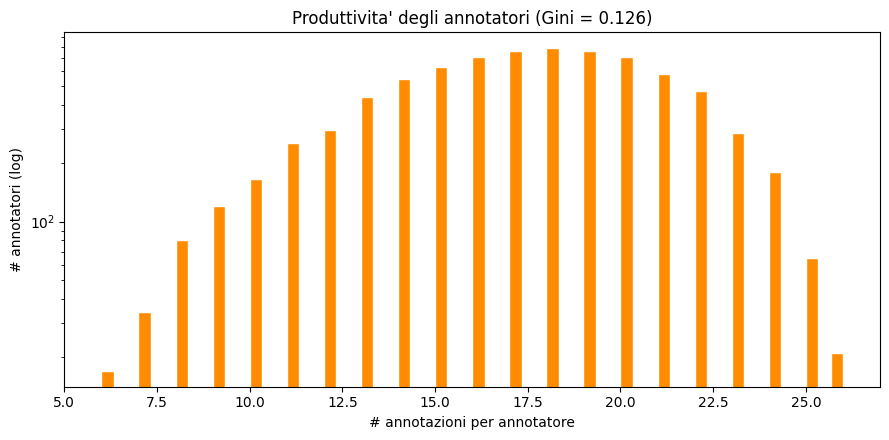

In [12]:
prod: dict = annotator_productivity(df)

print(
    f"Annotazioni per annotatore  --  media: {prod['mean']:.2f}, "
    f"mediana: {prod['median']:.2f}, max: {prod['max']}"
)
print(f"Indice di Gini: {prod['gini']:.4f}")
print(
    f"Quota di annotazioni prodotta dall'1% piu' produttivo: "
    f"{prod['top1pct_share'] * 100:.1f}%"
)

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(prod["counts"].values, bins=60, color="darkorange", edgecolor="white")
ax.set_yscale("log")
ax.set_title(f"Produttivita' degli annotatori (Gini = {prod['gini']:.3f})")
ax.set_xlabel("# annotazioni per annotatore")
ax.set_ylabel("# annotatori (log)")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_annotator_productivity.png", dpi=120, bbox_inches="tight")
plt.show()

Il coefficiente di Gini è basso, la distribuzione del numero di annotazioni per annotatore è approssimativamente uniforme.

### 2.8. - Distribuzione dei gruppi target

Per ciascuna delle otto macro-dimensioni protette (razza, religione, origine, genere, sessualità, età, disabilità, orientamento politico), aggreghiamo i dummy binari per contare quanti commenti del corpus sono stati etichettati come **bersaglio** di quel gruppo.

**Nota**: i dummy non sono mutuamente esclusivi — un commento può essere annotato come targeting simultaneo di più gruppi. La somma quindi non è il numero totale di commenti, ma il numero di occorrenze di targeting.

**Hook etico**: gli sbilanciamenti qui osservati (es. `target_race_black` >> `target_race_pacific_islander`) determineranno la qualità della performance del classificatore per sottogruppo. Gruppi sottorappresentati nei dati di training tipicamente ottengono recall basso, anche con accuracy globale alta. È il problema centrale del §4 (Fairness).

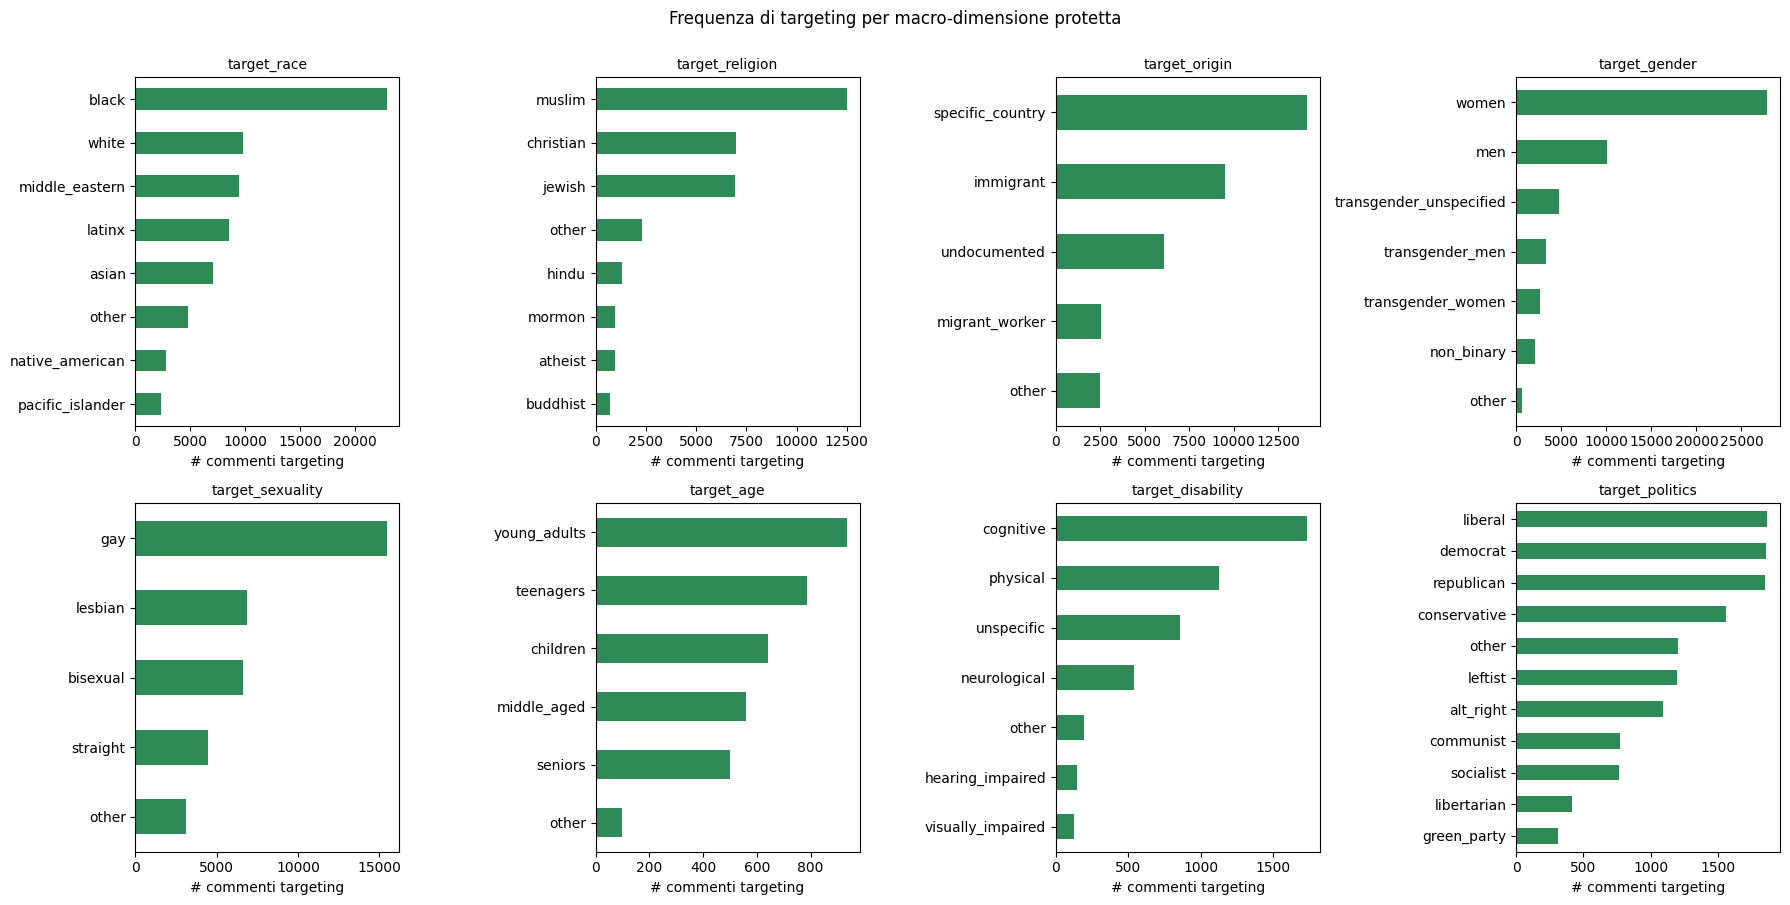

In [13]:
target_dims: list = [
    "target_race",
    "target_religion",
    "target_origin",
    "target_gender",
    "target_sexuality",
    "target_age",
    "target_disability",
    "target_politics",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, dim in zip(axes.flat, target_dims):
    dummies = [c for c in column_groups["target_groups"] if c.startswith(f"{dim}_")]
    counts = df[dummies].sum().sort_values(ascending=True)
    counts.index = [c.replace(f"{dim}_", "") for c in counts.index]
    counts.plot(kind="barh", ax=ax, color="seagreen")
    ax.set_title(dim, fontsize=10)
    ax.set_xlabel("# commenti targeting")
fig.suptitle("Frequenza di targeting per macro-dimensione protetta", y=1.00)
plt.tight_layout()
plt.show()

**Lettura delle asimmetrie.** Copertura per macro-dimensione: `gender` (12.8k commenti) e `race` (10.3k) dominano; `sexuality` (6.4k) e `origin` (6.1k) sono nel mezzo; `religion` (5.7k) e `politics` (1.4k) sotto la media; `age` (676) e `disability` (827) hanno copertura di un ordine di grandezza inferiore. Intra-dimensione lo squilibrio e' ancora piu' marcato: `target_race_black` >> `target_race_pacific_islander`, `target_religion_muslim` >> `target_religion_hindu`, e cosi' via.

**Implicazione per il §4.4.** I tre gruppi a copertura piu' bassa — `age`, `disability`, `politics` — sono i candidati naturali al recall basso del modello. Il caso di `disability` (827 commenti, ma `hate_rate` 47.9% al §4.2.1) sara' particolarmente delicato: poche istanze a tasso di hate piu' alto della media, terreno fertile per shortcut lessicale (il §5 verifichera' che il modello impara "menzione di disabilita' → hate" come euristica).

### 2.9. - Missing values

Identifichiamo le colonne con valori mancanti non trascurabili (> 1%). Nel dataset Measuring Hate Speech la presenza di `NaN` non è quasi mai "errore di registrazione" ma piuttosto:

- **Opt-out volontario** sull'auto-dichiarazione demografica (es. campi "prefer not to say" o rifiuti nelle survey post-annotazione).
- **Strutturali**: alcune colonne hanno senso solo per sottoinsiemi del corpus.

In [14]:
missing: dict = stats["missing_values"]
missing_filtered = {k: v for k, v in missing.items() if v >= 0.1}

if not missing_filtered:
    print("Nessuna colonna con missing >= 0.1%.")
else:
    missing_series = pd.Series(missing_filtered).sort_values(ascending=False)
    print(f"Colonne con missing >= 0.1% ({len(missing_series)} su {df.shape[1]}):\n")
    print(missing_series.to_string(float_format=lambda x: f"{x:5.2f}%"))

Nessuna colonna con missing >= 0.1%.


### 2.10. - Sintesi dell'EDA

Le evidenze raccolte vincolano le scelte etiche dei capitoli successivi:

- **Soggettivita' delle label** (§2.4): con N annotatori per commento, `hate_speech_score` e' una media di giudizi morali — non una verita' oggettiva. Il modello del §5 imparera' a riprodurre il *consenso aggregato di questo specifico pool*, non un concetto universale di hate speech.
- **Composizione per piattaforma** (§2.4.2.): la distribuzione disomogenea tra YouTube, Reddit e Twitter introduce un confounder strutturale. Ogni disparita' apparente per gruppo target nel §4 dovra' essere controllata per la piattaforma di provenienza, pena confondere bias del modello con effetti di norme editoriali differenziate.
- **Soglia di classificazione arbitraria** (§2.5): qualsiasi binarizzazione di `hate_speech_score` e' una decisione di policy, non tecnica. Sara' giustificata esplicitamente nel §5. Il boxplot rende visibile l'asimmetria delle code, decisiva per quantificare il costo di scelte di soglia.
- **Etichette sbilanciate** (§2.6.1.): label come `genocide` o `violence` quasi sempre nulle richiedono metriche robuste (F1, AUC-PR) e attenzione a falsi negativi.
- **Eterogeneita' del costrutto** (§2.6.2.): la correlazione non uniforme tra le 10 etichette mostra che `hate_speech_score` aggrega dimensioni semanticamente distinte. Vincola il §5 a rendere esplicito, in fase di spiegazione delle predizioni, quale componente dell'hate sta dominando.
- **Bias di campionamento degli annotatori** (§2.7.1.): la composizione del pool determina cosa il dataset chiama "hate". Sbilanciamenti ideologici o demografici sono il vero ground truth del bias di label — focus del §4.
- **Affidabilita' delle annotazioni** (§2.7.2.): la concentrazione della produttivita' (Gini) ridimensiona la nozione di "consenso del pool"; 
- **Sbilanciamento dei gruppi target** (§2.8): gruppi sottorappresentati avranno tipicamente recall basso. Driver del fairness audit del §4.
- **Missing demografici** (§2.9): Sono trascurabili.


### 2.11. - Costruzione dei df di lavoro

L'EDA del §2 ha trattato il dataset nella sua forma nativa: 135.556 righe, una per annotazione. Per i capitoli successivi questa granularità non è più funzionale: il §4 (Fairness) ragiona sul comportamento del modello *per commento*, il §5 (Interpretabilità) addestra un classificatore su commenti distinti, il §3 (Privacy) audita gli *annotatori* come individui.

Costruiamo qui due df aggregati che resteranno i materiali operativi del resto del notebook:

- **`df_comments`** — una riga per commento, con `hate_score` mediato sugli annotatori, dummies di target via majority vote, e i metadati nativi (`text`, `platform`). Materiale del §4 e del §5.
- **`df_annotators`** — una riga per annotatore, con QI demografiche native e statistiche aggregate sulla sua produzione (numero annotazioni, hate score medio assegnato, dispersione). Materiale del §3.

L'asimmetria di trattamento è dichiarata: `df_comments` viene esportato in `data/processed/` come materiale di lavoro stabile, mentre `df_annotators` **resta in memoria e non viene mai persistito su disco non-anonimizzato**. Ogni riga di `df_annotators` è un individuo identificato dalle sue QI demografiche, e la sua scrittura su filesystem violerebbe il principio di minimizzazione (GDPR art. 5(1)(c)) prima ancora che il §3 abbia operato. La versione esportabile di `df_annotators` arriva solo al §3.5.2., post-generalizzazione e suppression.

In [15]:
qi_native = column_groups["annotator_qi_summary"]
target_dummies = column_groups["target_groups"]

df_annotators = build_annotators_df(df, qi_native)
df_comments = build_comments_df(df, target_dummies)

df_comments.to_parquet(PROCESSED_DIR / "comments_aggregated.parquet", index=False)

print(f"df_annotators (in memoria):     {df_annotators.shape}")
print(f"df_comments  (esportato):       {df_comments.shape}")

df_annotators (in memoria):     (7912, 31)
df_comments  (esportato):       (39565, 71)


## 3. - Privacy

### 3.0. - Setup sezione privacy

In [16]:
from src.privacy import (
    compute_k_anonymity,
    compute_l_diversity,
    generalize_quasi_identifiers,
    generalize_multilabel_to_3way,
    suppress_singletons,
    GENDER_BAND,
    TRANS_BAND,
    EDUC_BAND,
    INCOME_BAND,
    IDEOLOGY_BAND,
    strategy,   
)

### 3.1. - Premessa

Il dataset Measuring Hate Speech raccoglie 135.556 annotazioni prodotte da 7.912 lavoratori reclutati su Amazon Mechanical Turk. Nessun identificatore diretto evidente — nome, email, recapito — e' incluso nel rilascio Hugging Face. La raccolta e' coperta da IRB approval dell'Universita' della California, Berkeley. Cio' non esaurisce l'obbligo di audit privacy: il dataset contiene piu' dimensioni demografiche sugli annotatori che, in combinazione, costituiscono un quasi-identificatore composito potenzialmente sufficiente a re-identificare singoli individui (GDPR art. 4: identificazione indiretta).

Il Considerando 26 fissa la soglia operativa: un dato e' anonimizzato solo se l'identificazione e' "ragionevolmente impossibile" considerando i mezzi tecnici disponibili al titolare e a terzi plausibili. L'auditor deve verificare empiricamente, non assumere, lo stato di anonimato.

Il capitolo procede in sei passi:
1. Dichiarare scope e perimetro delle QI (§3.2).
2. Rimuovere gli identificatori diretti (§3.3).
3. Misurare l'esposizione k sulle QI grezze (§3.4).
4. Applicare generalizzazione aggressiva 3-way (§3.5).
5. Applicare suppression dei singleton residui (§3.5.2.).
6. Verificare l-diversity sull'attributo sensibile (§3.6) e sintetizzare il trade-off (§3.7).

Tutte le analisi seguenti operano su `df_annotators` (§2.11). Il testo dei commenti — anch'esso un quasi-identificatore verso i post originali — non rientra in quest'audit; richiederebbe pipeline separata di rimozione PII testuali.

### 3.2. - Identificatori diretti, quasi-identificatori, scope

**Identificatore diretto** su `df_annotators`: `annotator_id`. (`comment_id` non e' presente in `df_annotators` per costruzione.)

**Quasi-identificatori (8)**: sei colonne QI summary del §2.3 + due colonne aggregate da dummies multi-label nel §3.5.

| # | Colonna | Cardinalita' nativa | Tipo |
|---|---|---|---|
| 1 | `annotator_gender` | 5 | categorica singola |
| 2 | `annotator_trans` | 3 | categorica singola |
| 3 | `annotator_age` | continua (~64 valori interi) | numerica |
| 4 | `annotator_educ` | 9 | categorica singola |
| 5 | `annotator_income` | 6 | categorica singola |
| 6 | `annotator_ideology` | 9 | categorica singola, **diventa SA al §3.6** |
| 7 | `annotator_race_3way` | aggregata da ~8 dummies multi-label | costruita al §3.5 |
| 8 | `annotator_sexuality_binary` | aggregata da ~4 dummies multi-label | costruita al §3.5 |

**Scope normativo: cosa abbiamo escluso e perche'**. Il dataset codifica come dummies multi-label tre dimensioni rilevanti ai sensi dell'art. 9 GDPR: race, sexuality, religion. Le prime due entrano nelle QI dopo aggregazione (§3.5). `annotator_religion_*` viene **esclusa** dalle QI per trattabilita' computazionale: aggiungere una nona dimensione, anche minimale, porterebbe lo spazio cartesiano post-generalizzazione sopra le 6.000 celle contro un pool di ~8.000 annotatori, oltre la soglia di applicabilita' di k-anonymity classica. L'esclusione e' operativa, non normativa: religion resta materiale potenzialmente sensibile e un audit completo a copertura art. 9 richiederebbe metodologia distinta (cfr. §3.7 sulla *curse of dimensionality*).

In [17]:
direct_identifiers = ["annotator_id"]
qi_summary = column_groups["annotator_qi_summary"]  # le 6 native

print(f"Identificatore diretto:  {direct_identifiers}")
print(f"\nQI summary native (6):")
for c in qi_summary:
    n = df_annotators[c].nunique(dropna=False)
    print(f"  {c:30s} {n:>4d} valori")

# Dummies multi-label sorgente per race e sexuality
race_dummies = [c for c in df_annotators.columns if c.startswith("annotator_race_")]
sexuality_dummies = [c for c in df_annotators.columns if c.startswith("annotator_sexuality_")]

print(f"\nDummies race (sorgente per race_3way): {len(race_dummies)}")
print(f"Dummies sexuality (sorgente per sexuality_binary): {len(sexuality_dummies)}")

Identificatore diretto:  ['annotator_id']

QI summary native (6):
  annotator_gender                  5 valori
  annotator_trans                   3 valori
  annotator_educ                    9 valori
  annotator_income                  6 valori
  annotator_ideology                9 valori
  annotator_age                    64 valori

Dummies race (sorgente per race_3way): 8
Dummies sexuality (sorgente per sexuality_binary): 4


### 3.3. - Rimozione degli identificatori diretti

`annotator_id` e' un intero sequenziale, *de facto* gia' pseudonimo rispetto all'identita' reale del lavoratore MTurk. Sostituirlo con un hash non aggiungerebbe protezione strutturale: chi possiede l'insieme degli ID nativi puo' ricostruire il mapping in tempo costante. La scelta corretta — coerentemente con il principio di minimizzazione (GDPR art. 5(1)(c)) — e' la **rimozione**: l'ID esce dal df del §3, che diventa il df-candidato-al-rilascio.

Il df nativo `df_annotators` con `annotator_id` continua a esistere in memoria per le aggregazioni del §4 (Fairness), dove la chiave annotator e' funzionalmente indispensabile per analisi cross-annotatore. La separazione operativa (*df anonymous per il release*, *df nativo per l'analisi interna*) riflette la distinzione strutturale tra pubblicazione e ricerca; sara' ripresa in chiusura del §3.7.

In [18]:
df_anon = df_annotators.drop(columns=direct_identifiers).copy()

### 3.4. - k-anonymity sui dati grezzi

Un dataset e' **k-anonimo** rispetto a un insieme di QI se ogni combinazione di valori delle QI compare in almeno k record (Sweeney 2002). Il k effettivo e' il minimo della distribuzione dei conteggi di gruppo — l'esposizione del record peggiore.

Il singolo k_min e' tuttavia dominato dall'outlier piu' esposto e poco informativo della **tipica** esposizione del pool. Riportiamo quindi un panel esteso: k mediano e quartili descrivono il caso medio, mentre la curva di sopravvivenza dell'anonimato — quota di annotatori protetti a soglie crescenti di k — restituisce la forma completa della distribuzione di rischio.

Prima del calcolo, fissiamo la dimensionalita' dello spazio QI. La k-anonymity grezza qui calcolata copre le **sei QI summary native** (escluse race e sexuality, che esistono solo come dummies multi-label a questo stadio e verranno aggregate al §3.5). Una densita' bassa (occupato/teorico) indica spazio sparse: in regimi sparse, i singleton sono strutturali, non accidentali (Aggarwal 2005).

In [19]:
# QI grezze: solo le 6 summary native (race e sexuality entrano al §3.5)
qi_raw = qi_summary

theoretical_raw = int(np.prod([df_anon[c].nunique(dropna=False) for c in qi_raw]))
occupied_raw = df_anon.groupby(qi_raw, dropna=False).ngroups
density_raw = occupied_raw / theoretical_raw

print(f"Spazio QI teorico:   {theoretical_raw:>10,}")
print(f"Spazio QI occupato:  {occupied_raw:>10,}")
print(f"Densità:            {density_raw:.2%}")

Spazio QI teorico:      466,560
Spazio QI occupato:       4,314
Densità:            0.92%


k_min (caso peggiore):       1
k_mediano:                   1.0
k_Q1 / k_Q3:                 1 / 2
Combinazioni QI distinte:    4,314
Quota singleton (k=1):       58.0%
Annotatori in singleton:     2,502
Protetti a k>=2:             1,812  (42.0%)
Protetti a k>=5:             230  (5.3%)
Protetti a k>=10:            19


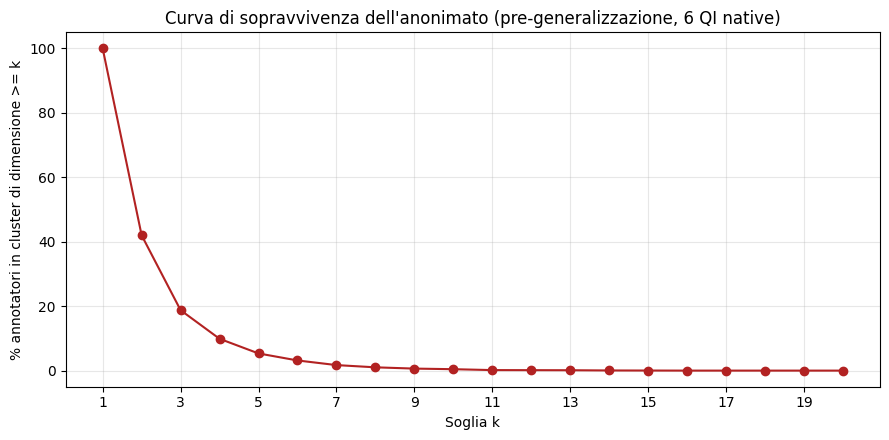

In [20]:
k_raw = compute_k_anonymity(df_anon, qi_raw)
dist_raw = k_raw["distribution"]

print(f"k_min (caso peggiore):       {dist_raw.min()}")
print(f"k_mediano:                   {dist_raw.median():.1f}")
print(f"k_Q1 / k_Q3:                 {dist_raw.quantile(0.25):.0f} / {dist_raw.quantile(0.75):.0f}")
print(f"Combinazioni QI distinte:    {len(dist_raw):,}")
print(f"Quota singleton (k=1):       {(dist_raw == 1).mean() * 100:.1f}%")
print(f"Annotatori in singleton:     {(dist_raw == 1).sum():,}")
print(f"Protetti a k>=2:             {(dist_raw >= 2).sum():,}  ({(dist_raw >= 2).mean()*100:.1f}%)")
print(f"Protetti a k>=5:             {(dist_raw >= 5).sum():,}  ({(dist_raw >= 5).mean()*100:.1f}%)")
print(f"Protetti a k>=10:            {(dist_raw >= 10).sum():,}")

fig, ax = plt.subplots(figsize=(9, 4.5))
k_thresholds = np.arange(1, 21)
share_protected = [(dist_raw >= k).mean() * 100 for k in k_thresholds]
ax.plot(k_thresholds, share_protected, marker="o", color="firebrick")
ax.set_xlabel("Soglia k")
ax.set_ylabel("% annotatori in cluster di dimensione >= k")
ax.set_title("Curva di sopravvivenza dell'anonimato (pre-generalizzazione, 6 QI native)")
ax.grid(alpha=0.3)
ax.set_xticks(k_thresholds[::2])
plt.tight_layout()
fig.savefig(FIGURES_DIR / "privacy_k_survival_pre.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.5.1. - Generalizzazione aggressiva

La generalizzazione opera su otto QI complessive. Per cinque di queste applichiamo collasso 3-way (gender, age, educ, income, ideology). Per altre tre la trasformazione e' piu' strutturale:

- `annotator_trans` viene collassato a binario (`no_or_unknown` assorbe sia `no` sia `prefer_not_to_say`). La letteratura sulla non-response in survey LGBTQ+ documenta che `prefer_not_to_say` ha distribuzione vicina a quella di `no`; collassarli riduce la dimensionalita' senza significativa perdita di segnale.
- `annotator_race_3way` aggrega le dummies multi-label native in `white / black / other_or_multiracial`. La partizione cattura l'asse di disparita' principale documentato in letteratura US sull'hate speech (Sap et al. 2019: white-vs-black gap). Confluiscono in `other_or_multiracial` asian, latinx, native_american, pacific_islander, middle_eastern, other, e tutti i casi multi-razziali.
- `annotator_sexuality_binary` aggrega le dummies multi-label native in `straight / non_straight`. La letteratura sull'anti-LGBTQ+ hate speech documenta la disparita' principale come "etero vs non-etero" piuttosto che per identita' specifica; il binario e' la rappresentazione piu' protettiva e analiticamente piu' informativa.

Le scelte di binning per le altre QI:

- **`annotator_gender`** → `male / female / other_or_missing`. Preserva la disparita' principale (Sap et al. 2019) senza spaccare le minoranze di genere in singleton.
- **`annotator_age`** → `under-30 / 30-50 / over-50`. La distribuzione MTurk-USA ha pochi over-65 (~3-5%), che finirebbero in singleton anche con bin piu' fini.
- **`annotator_educ`** → `high_school_or_lower / some_college / masters_or_higher`. Tre fasce che catturano i salti formativi rilevanti.
- **`annotator_income`** → `low / mid / high`. Collasso simmetrico delle code.
- **`annotator_ideology`** → `conservative / moderate_or_no_opinion / liberal`. Si perde la distinzione moderato/estremo. Resta come SA al §3.6.

**Trade-off privacy/utility**. Il collasso di gender, ideology, race e sexuality rimuove proprio le dimensioni a maggior valore predittivo per l'audit di fairness del §4. La pipeline del §4 lavorera' quindi sul df *nativo* `df_annotators`, esplicitando una tensione strutturale tra protezione degli annotatori (qui) e granularita' necessaria all'analisi di bias di label (§4). Le due dimensioni etiche del corso si tirano in direzioni opposte; il notebook non le riconcilia, le rende visibili.

In [21]:
# Pre-trasformazione 1: race da multi-label a 3-way
df_anon["annotator_race_3way"] = generalize_multilabel_to_3way(
    df_anon,
    prefix="annotator_race_",
    primary_categories=["white", "black"],
    other_label="other_or_multiracial",
)

# Pre-trasformazione 2: sexuality da multi-label a binario
df_anon["annotator_sexuality_binary"] = generalize_multilabel_to_3way(
    df_anon,
    prefix="annotator_sexuality_",
    primary_categories=["straight"],
    other_label="non_straight",
)

# Verifica distribuzioni
for col in ["annotator_race_3way", "annotator_sexuality_binary"]:
    print(f"\nDistribuzione {col}:")
    counts = df_anon[col].value_counts(dropna=False)
    pct = df_anon[col].value_counts(normalize=True, dropna=False) * 100
    for val in counts.index:
        print(f"  {val:30s} {counts[val]:>6,}  ({pct[val]:.2f}%)")


Distribuzione annotator_race_3way:
  white                           5,846  (73.89%)
  other_or_multiracial            1,447  (18.29%)
  black                             619  (7.82%)

Distribuzione annotator_sexuality_binary:
  straight                        6,706  (84.76%)
  non_straight                    1,206  (15.24%)


In [22]:
for col, mapping in strategy.items():
    if isinstance(mapping, dict):
        native = set(df_anon[col].dropna().unique())
        mapped = set(mapping.keys())
        missing = native - mapped
        if missing:
            print(f"WARNING: {col} ha valori nativi non mappati: {missing}")

In [23]:
df_generalized = generalize_quasi_identifiers(df_anon, strategy)

# QI complete dopo la generalizzazione
qi_columns = list(qi_summary) + ["annotator_race_3way", "annotator_sexuality_binary"]

print("Distribuzioni post-generalizzazione:")
for col in qi_columns:
    print(f"\n  {col}:")
    print(df_generalized[col].value_counts(dropna=False).to_string())

k_gen = compute_k_anonymity(df_generalized, qi_columns)
dist_gen = k_gen["distribution"]

theoretical_gen = int(np.prod([df_generalized[c].nunique(dropna=False) for c in qi_columns]))
occupied_gen = len(dist_gen)

print(f"\n--- Confronto pre/post-generalizzazione ---")
print(f"Spazio teorico:        {theoretical_raw:>8,}  →  {theoretical_gen:>8,}")
print(f"Spazio occupato:       {occupied_raw:>8,}  →  {occupied_gen:>8,}")
print(f"k_min:                 {dist_raw.min():>8}  →  {dist_gen.min():>8}")
print(f"k_mediano:             {dist_raw.median():>8.1f}  →  {dist_gen.median():>8.1f}")
print(f"Quota singleton:       {(dist_raw==1).mean()*100:>7.2f}%  →  {(dist_gen==1).mean()*100:>7.2f}%")
print(f"Protetti k>=2:         {(dist_raw>=2).mean()*100:>7.2f}%  →  {(dist_gen>=2).mean()*100:>7.2f}%")
print(f"Protetti k>=5:         {(dist_raw>=5).mean()*100:>7.2f}%  →  {(dist_gen>=5).mean()*100:>7.2f}%")

Distribuzioni post-generalizzazione:

  annotator_gender:
annotator_gender
female              4426
male                3392
other_or_missing      94

  annotator_trans:
annotator_trans
no_or_unknown    7845
yes                67

  annotator_educ:
annotator_educ
some_college            6018
masters_or_higher        994
high_school_or_lower     899
NaN                        1

  annotator_income:
annotator_income
low     3696
mid     3079
high    1131
NaN        6

  annotator_ideology:
annotator_ideology
liberal                   4275
conservative              2019
moderate_or_no_opinion    1616
NaN                          2

  annotator_age:
annotator_age
30-50       4465
under-30    2172
over-50     1270
NaN            5

  annotator_race_3way:
annotator_race_3way
white                   5846
other_or_multiracial    1447
black                    619

  annotator_sexuality_binary:
annotator_sexuality_binary
straight        6706
non_straight    1206

--- Confronto pre/post-generaliz

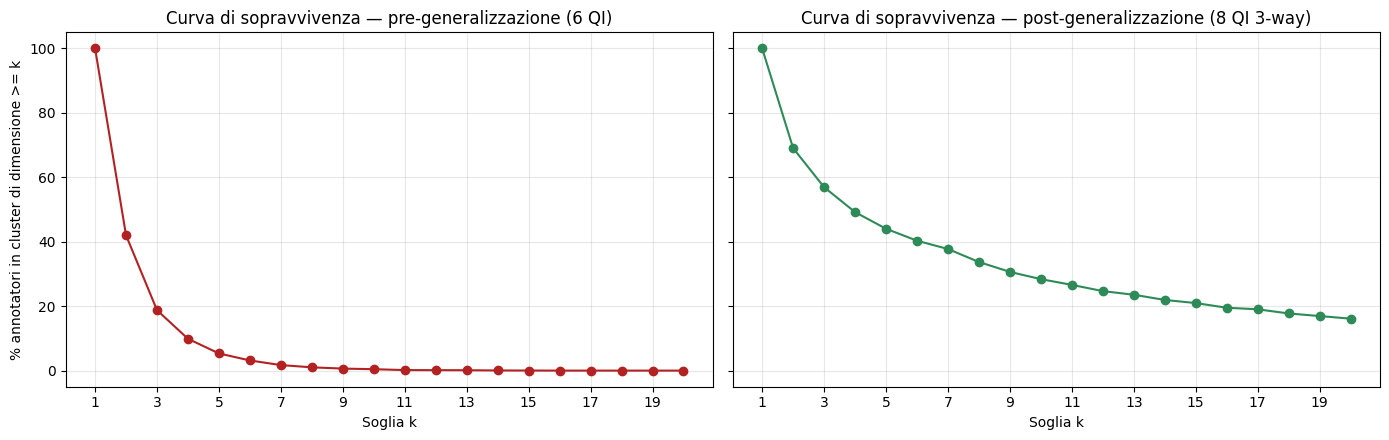

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, (data, label, color) in zip(
    axes,
    [(dist_raw, "pre-generalizzazione (6 QI)", "firebrick"),
     (dist_gen, "post-generalizzazione (8 QI 3-way)", "seagreen")],
):
    share = [(data >= k).mean() * 100 for k in k_thresholds]
    ax.plot(k_thresholds, share, marker="o", color=color)
    ax.set_xlabel("Soglia k")
    ax.set_title(f"Curva di sopravvivenza — {label}")
    ax.grid(alpha=0.3)
    ax.set_xticks(k_thresholds[::2])

axes[0].set_ylabel("% annotatori in cluster di dimensione >= k")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "privacy_k_survival_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.5.2. - Suppression dei singleton

La generalizzazione del §3.5 riduce drasticamente lo spazio cartesiano ma non azzera i singleton: combinazioni demografiche rare (es. uomini trans over-50 high-income conservative black non_straight) restano isolate per ragioni strutturali del pool, non per artefatti del binning. Per raggiungere k = 2 sull'intero df residuo applichiamo soppressione: rimuoviamo gli annotatori in classi di equivalenza di dimensione 1, e quantifichiamo il costo in copertura del pool.

**Costo distributivo della suppression**. La soppressione non e' un'operazione neutra. Gli annotatori rimossi sono per definizione i piu' demograficamente atipici — e le loro annotazioni sono proprio quelle che evitano l'omogeneizzazione del giudizio nel pool. La privacy ha un costo che ricade sproporzionatamente sulle minoranze intersezionali: chi sta in piu' categorie minoritarie ha QI rare, quindi cluster piccoli, quindi probabilita' alta di essere soppresso. La letteratura su differential privacy chiama questa proprieta' *equity cost of privacy* (Bagdasaryan, Poursaeed & Shmatikov 2019); si estende naturalmente a k-anonymity con suppression.

In [25]:
df_anonymous, supp_stats = suppress_singletons(df_generalized, qi_columns, k_threshold=2)

print(f"Annotatori pre-suppression:    {len(df_generalized):,}")
print(f"Annotatori soppressi:          {supp_stats['n_removed']:,}")
print(f"Quota pool persa:              {supp_stats['share_removed']*100:.2f}%")
print(f"Gruppi QI eliminati (k=1):     {supp_stats['n_groups_removed']:,}")
print(f"Annotatori residui:            {len(df_anonymous):,}")
print(f"k_min post-suppression:        {supp_stats['k_min_post']}")

df_generalized_with_size = df_generalized.copy()
df_generalized_with_size["_group_size"] = df_generalized.groupby(
    qi_columns, dropna=False
)[qi_columns[0]].transform("size")

df_suppressed_only = df_generalized_with_size[df_generalized_with_size["_group_size"] < 2]

print(f"\n--- Profili sovra-rappresentati tra i soppressi ---")
print(f"Totale soppressi: {len(df_suppressed_only):,}")
for col in qi_columns:
    native_dist = df_generalized[col].value_counts(normalize=True, dropna=False)
    suppressed_dist = df_suppressed_only[col].value_counts(normalize=True, dropna=False)
    delta = (suppressed_dist - native_dist).sort_values(ascending=False).head(2)
    print(f"\n  {col}:")
    for val, d in delta.items():
        sign = "+" if d >= 0 else ""
        print(f"    {str(val):30s} {sign}{d*100:5.2f} punti percentuali")

Annotatori pre-suppression:    7,912
Annotatori soppressi:          192
Quota pool persa:              2.43%
Gruppi QI eliminati (k=1):     192
Annotatori residui:            7,720
k_min post-suppression:        2

--- Profili sovra-rappresentati tra i soppressi ---
Totale soppressi: 192

  annotator_gender:
    other_or_missing               +17.04 punti percentuali
    male                           -4.33 punti percentuali

  annotator_trans:
    yes                            +12.17 punti percentuali
    no_or_unknown                  -12.17 punti percentuali

  annotator_educ:
    masters_or_higher              +23.90 punti percentuali
    high_school_or_lower           +15.20 punti percentuali

  annotator_income:
    high                           +12.27 punti percentuali
    nan                            + 3.05 punti percentuali

  annotator_ideology:
    moderate_or_no_opinion         +18.12 punti percentuali
    nan                            + 1.02 punti percentuali

  annot

In [26]:
df_anonymous.to_parquet(
    PROCESSED_DIR / "annotators_anonymous.parquet", index=False
)
print(f"\nFile esportato: {PROCESSED_DIR / 'annotators_anonymous.parquet'}")
print(f"Shape: {df_anonymous.shape}")


File esportato: c:\Users\LENOVO\Documents\dev\measuring-hate-speech-audit\data\processed\annotators_anonymous.parquet
Shape: (7720, 32)


### 3.6. - l-diversity sull'attributo sensibile

La k-anonymity protegge dall'identificazione del record ma non dall'inferenza dell'attributo sensibile (Machanavajjhala et al. 2007). Se un gruppo k-anonimo contiene k record che condividono lo stesso valore sensibile, sapere che un soggetto appartiene al gruppo equivale a conoscerne l'attributo.

**Attributo sensibile**: `annotator_ideology` (post-generalizzazione: 3 valori). E' opinione politica ai sensi dell'art. 9 GDPR ed e' direttamente predittiva dello schema di etichettatura applicato dall'annotatore al hate speech. La l-diversity massima ottenibile, dato che la cardinalita' e' 3, e' anch'essa 3; il target operativo realistico e' l >= 2.

Le QI per la l-diversity sono sette (`annotator_ideology` esce dalle QI per entrare come SA). Il df di partenza e' quello post-suppression.

Attributo sensibile:                annotator_ideology
QI per l-diversity (7): ['annotator_gender', 'annotator_trans', 'annotator_educ', 'annotator_income', 'annotator_age', 'annotator_race_3way', 'annotator_sexuality_binary']

l effettiva:                        1
Gruppi k-anonimi:                   208
Quota gruppi con l >= 2:            64.42%
Quota gruppi con l = 3 (max):       41.35%
Gruppi omogenei (l=1):              74


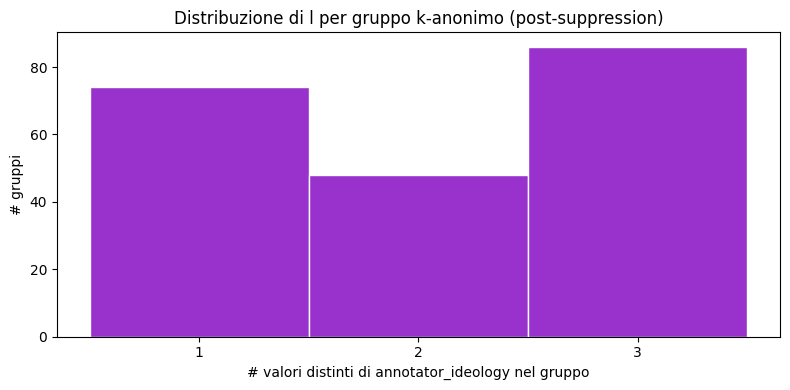

In [27]:
qi_for_ldiv = [c for c in qi_columns if c != "annotator_ideology"]
sensitive_col = "annotator_ideology"

l_stats = compute_l_diversity(
    df_anonymous,
    qi_columns=qi_for_ldiv,
    sensitive_column=sensitive_col,
)

print(f"Attributo sensibile:                {sensitive_col}")
print(f"QI per l-diversity ({len(qi_for_ldiv)}): {qi_for_ldiv}")
print()
print(f"l effettiva:                        {l_stats['l_effective']}")
print(f"Gruppi k-anonimi:                   {l_stats['n_groups']:,}")
print(f"Quota gruppi con l >= 2:            {l_stats['share_l_geq_2']*100:.2f}%")
print(f"Quota gruppi con l = 3 (max):       {l_stats['share_l_geq_3']*100:.2f}%")
print(f"Gruppi omogenei (l=1):              {int((l_stats['distribution']==1).sum()):,}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    l_stats["distribution"].values,
    bins=range(1, 5),
    color="darkorchid", edgecolor="white", align="left",
)
ax.set_xticks([1, 2, 3])
ax.set_title("Distribuzione di l per gruppo k-anonimo (post-suppression)")
ax.set_xlabel("# valori distinti di annotator_ideology nel gruppo")
ax.set_ylabel("# gruppi")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "privacy_l_diversity_post.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.7. - Sintesi: quantificazione di un trade-off

Il capitolo ha trattato la privacy non come un obiettivo da raggiungere ma come un trade-off da quantificare.

- **Stato grezzo (§3.4)**: con sei QI summary native, lo spazio cartesiano teorico contava 466.560 celle contro 4.314 effettivamente popolate da 7.912 annotatori — una densita' dello 0.92%, regime sparso. Il k_min e' 1, il k_mediano e' 1, e il **58.0% degli annotatori si trova in cluster singoletti**: re-identificazione plausibile tramite la sola combinazione di attributi demografici. Solo il 5.33% del pool e' protetto a k >= 5, e diciannove annotatori a k >= 10.

- **Post-generalizzazione 3-way (§3.5)**: collassare otto dimensioni (gender 3-way, trans binarizzato, age in tre fasce, educ 3-way, income 3-way, ideology 3-way, race aggregata in white/black/other_or_multiracial, sexuality binarizzata in straight/non_straight) riduce lo spazio cartesiano teorico di un fattore ~50 (da 466.560 a 9.216) e quello occupato di un fattore ~7 (da 4.314 a 620 celle). La quota di singleton scende dal 58.0% al 30.97%, e la protezione a k >= 5 passa dal 5.33% al 44.03%. Il k_min resta 1: la generalizzazione, per quanto aggressiva, non azzera l'esposizione del record peggiore.

- **Post-suppression (§3.5.2.)**: rimuovendo gli annotatori in classi di equivalenza singolari raggiungiamo k_min = 2 sull'intero df residuo. Costo quantitativo: **192 annotatori soppressi, il 2.43% del pool** — significativamente sotto le stime conservative. Il caso e' favorevole rispetto alla letteratura sulla curse of dimensionality: lo spazio QI a otto dimensioni 3-way, pur teoricamente ostile, si rivela computazionalmente gestibile per il pool MTurk a disposizione.

- **Costo distributivo della suppression**: il profilo dei 192 soppressi e' marcatamente intersezionale. Rispetto alla distribuzione globale, sono sovra-rappresentati: persone trans (+12.17 pp), `non_straight` (+40.49 pp), `other_or_multiracial` (+27.54 pp), black (+13.01 pp), con gender `other_or_missing` (+17.04 pp), education ai due estremi della distribuzione (masters_or_higher +23.90 pp e high_school_or_lower +15.20 pp), `moderate_or_no_opinion` ideologico (+18.12 pp), e fasce di eta' estreme (under-30 +9.01 pp e over-50 +7.39 pp). Il pattern conferma quantitativamente quanto teorizzato in apertura: la suppression colpisce sproporzionatamente i profili intersezionali rari — persone con identita' minoritarie sovrapposte, esattamente quelle che il §4 vorrebbe poter analizzare per evitare omogeneizzazione del giudizio nel pool. La letteratura su differential privacy ha tematizzato questa proprieta' come *equity cost of privacy* (Bagdasaryan, Poursaeed & Shmatikov 2019); il principio si estende a k-anonymity con suppression, e il dataset ne fornisce un'illustrazione netta.

- **l-diversity (§3.6)**: il df anonymous non soddisfa l = 2 globalmente — l_effective resta 1 a causa di **74 gruppi k-anonimi ideologicamente omogenei** (il 35.58% dei 208 cluster post-suppression). Il 64.42% dei gruppi soddisfa l >= 2 e il 41.35% raggiunge la l massima ottenibile dato il dominio post-generalizzazione (l = 3). I 74 gruppi omogenei sono il residuo strutturale di un pool ideologicamente polarizzato: una volta partizionato per sette QI demografiche aggregate, in oltre un terzo dei cluster gli annotatori condividono anche l'ideologia generalizzata. Sono gli annotatori esposti a omogeneity attack ideologico: chi riconduce un soggetto a uno di questi cluster ne inferisce l'orientamento politico senza ambiguita'. La protezione richiederebbe ulteriore suppression o generalizzazione, con costi sul pool che il capitolo ha scelto di non pagare — la documentazione del finding sostituisce qui la mitigazione.

**Pseudo-anonimizzazione, una nota sul framework normativo**. Il capitolo ha deliberatamente scartato la pseudo-anonimizzazione come tecnica per questo dataset. Gli identificatori nativi sono interi sequenziali, gia' pseudonimi rispetto all'identita' MTurk: trasformarli in hash sarebbe stato cosmetico. La scelta corretta — coerente con il principio di minimizzazione (GDPR art. 5(1)(c)) — e' stata la rimozione (§3.3). Cio' mostra che la distinzione anonimizzazione/pseudo-anonimizzazione del Considerando 26 non e' interscambiabile in modo meccanico: dipende dalla natura strutturale degli identificatori, non solo dalla tecnica nominalmente applicata.

**La curse of dimensionality come finding strutturale**. La difficolta' di raggiungere k operativo su questo dataset esemplifica un limite teorico noto: Aggarwal (2005) mostra che il costo informativo della k-anonymity tramite generalizzazione cresce esponenzialmente con il numero di QI. L'esclusione di `annotator_religion_*` dalle QI (§3.2) e' una manifestazione concreta di questo limite: una nona QI 3-way avrebbe portato lo spazio cartesiano oltre il triplo del pool. Il fatto che la suppression sia rimasta sotto il 3% e' specifico del nostro perimetro di otto QI; estendere la copertura art. 9 a religion avrebbe spostato il caso in regime ostile. Le direzioni di approfondimento non implementate — *differential privacy* (Dwork 2006) che agisce su query e non su dataset, e *synthetic data generation* — sono il punto di approdo naturale per coperture piu' estese: non "alternative migliori" tout court, ma framework diversi che si attivano dove k-anonymity esaurisce il suo regime.

**Sui valori mancanti**. I `NaN` nelle QI — opt-out volontari rilevati al §2.9 — vengono trattati da `groupby(dropna=False)` come categoria propria. Il loro raggruppamento naturale produce cluster di "rifiutanti seriali" che la suppression tende a eliminare (income e ideology compaiono con `nan` tra i soppressi sovra-rappresentati, rispettivamente +3.05 pp e +1.02 pp). La pipeline rispetta la non-dichiarazione come scelta, non come dato mancante da imputare — coerentemente con il principio che la privacy si serve onorando l'opacita' richiesta dal soggetto.

**Aggancio al §4**. Le metriche di fairness del §4 lavoreranno sul df *nativo* `df_annotators` — non sul df anonymous prodotto qui. La scelta riflette la posizione operativa dichiarata al §3.3: l'audit interno di disparita' per gruppo demografico degli annotatori richiede granularita' che la privacy del rilascio avrebbe sacrificato. Il df del §3 documenta cosa sarebbe necessario pubblicare; il df del §4 documenta cosa l'auditor deve poter analizzare. La distinzione tra pubblicazione e ricerca e' la struttura normativa entro cui il framework FAccT opera in pratica e l'asimmetria distributiva della suppression osservata qui (§3.5.2.) anticipa una tensione metodologica che il §4 affrontera' in proprio: ogni metrica di fairness calcolata per gruppi sottili poggia su sottocampioni la cui struttura di rarita' e' la stessa che la privacy ha appena reso visibile.

## 4. - Audit algoritmico

### 4.0. - Setup e definizione del contesto

Il capitolo conduce l'audit algoritmico di un classificatore di hate speech addestrato su Measuring Hate Speech, seguendo le sei fasi canoniche del framework: definizione del contesto, identificazione delle feature sensibili, analisi dei dati, valutazione del modello, mitigazione del bias, documentazione (Bellamy et al. 2019; Raji & Buolamwini 2019). Le prime tre strategie di mitigazione — pre-processing (al §4.2), in-processing e post-processing (al §5) — strutturano la sequenza del capitolo.

**Obiettivo del modello sotto audit**. Un classificatore binario *hate / non-hate* a partire dal testo del commento. La binarizzazione di `hate_speech_score` (continuo, ~[-4, +4]) avviene a soglia 0.5 — scelta convenzionale che eredita le limitazioni dichiarate al §2.5: ogni soglia ridistribuisce in modo asimmetrico falsi positivi e falsi negativi tra gruppi target. La discussione delle conseguenze viene ripresa al §4.4.

**Decisioni automatizzate plausibili**. Moderazione di contenuti su piattaforme social (rimozione automatica, riduzione di visibilità, flagging per revisione umana), filtri di sicurezza per modelli generativi, pre-screening di segnalazioni utente. In ciascun caso, falsi positivi e falsi negativi hanno costi distinti — il falso positivo silenzia un parlante legittimo, il falso negativo lascia circolare hate; entrambi gravano in modo asimmetrico sui gruppi marginalizzati (Davidson, Bhattacharya & Weber 2019; Sap et al. 2019).

**Gruppi potenzialmente impattati**. Le otto macro-dimensioni di gruppo target codificate nel dataset: razza, religione, origine, genere, sessualità, età, disabilità, orientamento politico. Ciascuna aggregata via majority vote dei dummies di livello fine al §2.11 (`df_comments`).

**Posizionamento rispetto al §3**. Il capitolo lavora su due df: `df_comments` (esportato al §2.11, privo di QI annotatori per costruzione) come materiale principale, e `df_anonymous` (esportato al §3.5.2.) per la sotto-analisi del §4.1 sul bias di annotazione residuo. Il df nativo `df_annotators` con QI fini *non* viene utilizzato — la scelta riflette il framework di anonimizzazione del corso, che tratta come "dato personale" qualunque dataset di QI demografiche non generalizzate. La perdita di granularità è una conseguenza voluta del trade-off privacy/fairness dichiarato al §3.7.

**Feature sensibili identificate**. La fase 2 dell'audit algoritmico richiede di nominare esplicitamente gli attributi rispetto a cui si misura la fairness:

- **Per il §4.1** (bias di annotazione): le otto QI generalizzate degli annotatori in `df_anonymous`.
- **Per il §4.2 e §4.4** (bias del modello): le otto macro-dimensioni dei gruppi target del commento (`target_race`, `target_religion`, etc.).

La distinzione non è cosmetica: il §4.1 audita *chi ha costruito le etichette*, il §4.2-§4.4 audita *chi è giudicato dal modello che le riproduce*.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
)
from src.fairness import (
    compute_annotator_target_asymmetry,
    compute_target_representation,
    primary_target,
    per_group_metrics,
    compute_fairness_metrics,
)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 23
np.random.seed(RANDOM_STATE)

In [29]:
df_comments = pd.read_parquet(PROCESSED_DIR / "comments_aggregated.parquet")
df_anonymous = pd.read_parquet(PROCESSED_DIR / "annotators_anonymous.parquet")
df_comments["target_any"] = df_comments[target_dims].any(axis=1)

print(f"df_comments:   {df_comments.shape}")
print(f"df_anonymous:  {df_anonymous.shape}")

df_comments:   (39565, 72)
df_anonymous:  (7720, 32)


### 4.1. - Bias residuo di annotazione

Prima di auditare il modello, esaminiamo il bias *del processo di annotazione* — il bias che il dataset incorpora a monte di qualunque classificatore. La domanda operativa: gli annotatori appartenenti a una specifica categoria demografica giudicano in modo sistematicamente diverso i commenti che bersagliano la loro stessa categoria (o categorie con cui hanno frizione storica)?

Risposte affermative documentate in letteratura includono il *gap di moderazione* tra annotatori bianchi e neri sui commenti che usano African American English (Sap et al. 2019), e l'effetto di identita' minoritaria sull'identificazione di slur reclaimed (Davani et al. 2022). La domanda è classificabile come *bias di misura*: l'etichetta `hate_speech_score`, costruita come aggregato di giudizi soggettivi, riflette la composizione del pool quanto l'oggettivita' del fenomeno.

**Vincolo metodologico**. L'analisi opera su `df_anonymous` (7.720 annotatori, post-suppression del §3.5.2.), joinato con il df grezzo di annotazioni per ricostruire il legame annotatore-commento. Le QI sono generalizzate 3-way: pattern fini (es. *extremely_conservative* vs *slightly_conservative*) non sono visibili. L'equity cost del §3 ha un riflesso diretto qui: i 192 annotatori soppressi erano intersezionali (LGBTQ+, multirazziali) — proprio il gruppo demografico la cui asimmetria di giudizio sarebbe stata più informativa.

### 4.1.1. - Costruzione del df ponte

Il df anonymous prodotto al §3 non conserva `annotator_id` (rimosso al §3.3 per minimizzazione). Il legame annotazione-annotatore non può quindi essere ricostruito via join diretto. Procediamo via **join sulle QI generalizzate**: rigeneriamo le otto QI 3-way sul df grezzo, estraiamo da `df_anonymous` l'insieme delle combinazioni QI sopravvissute alla suppression, e filtriamo il df grezzo per quelle combinazioni.

Il filtro è equivalente al join via ID *modulo casi limite* che non si verificano per costruzione: la suppression elimina interi gruppi QI di dimensione 1, quindi ogni combinazione presente in `df_anonymous` corrisponde a uno o più annotatori sopravvissuti, e le loro annotazioni vengono recuperate integralmente. La pipeline rispetta il principio di minimizzazione del §3 senza re-introdurre identificatori.

In [30]:
df_for_join = df.copy()

df_for_join["annotator_race_3way"] = generalize_multilabel_to_3way(
    df_for_join,
    prefix="annotator_race_",
    primary_categories=["white", "black"],
    other_label="other_or_multiracial",
)
df_for_join["annotator_sexuality_binary"] = generalize_multilabel_to_3way(
    df_for_join,
    prefix="annotator_sexuality_",
    primary_categories=["straight"],
    other_label="non_straight",
)

df_for_join = generalize_quasi_identifiers(df_for_join, strategy)

qi_join_cols = list(qi_summary) + ["annotator_race_3way", "annotator_sexuality_binary"]

valid_combos = df_anonymous[qi_join_cols].drop_duplicates()
print(f"Combinazioni QI valide (post-suppression): {len(valid_combos):,}")

df_annotation_anon = df_for_join.merge(
    valid_combos,
    on=qi_join_cols,
    how="inner",
)

print(f"\nAnnotazioni totali nel df grezzo:        {len(df):,}")
print(f"Annotazioni dopo filtro anonymous:        {len(df_annotation_anon):,}")
print(f"Annotazioni perse (annotatori soppressi): {len(df) - len(df_annotation_anon):,}")
print(f"Quota persa:                              {(len(df) - len(df_annotation_anon))/len(df)*100:.2f}%")

Combinazioni QI valide (post-suppression): 428

Annotazioni totali nel df grezzo:        135,556
Annotazioni dopo filtro anonymous:        132,237
Annotazioni perse (annotatori soppressi): 3,319
Quota persa:                              2.45%


### 4.1.2. - Asimmetria di giudizio per categoria annotatore × target

Per ogni coppia (QI annotatore, macro-dimensione target), calcoliamo il `hate_score` medio assegnato agli annotatori di quella categoria sui commenti che bersagliano quel gruppo. Confrontiamo poi con lo `hate_score` medio assegnato dagli annotatori *non* appartenenti alla categoria. La differenza — se sistematicamente positiva o negativa — misura il bias di in-group/out-group nella moderazione.

L'effetto atteso, sulla base della letteratura: annotatori appartenenti a un gruppo minoritario sono *piu' severi* nel giudicare commenti che bersagliano il loro stesso gruppo. È l'ipotesi nulla naturale; la sua assenza sarebbe il finding sorprendente.

In [31]:
df_comments["hate_binary"] = (df_comments["hate_score_mean"] > 0.5).astype(int)
df_representation = compute_target_representation(df_comments, target_dims)
print(df_representation.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

     dimension  n_comments  share_dataset  hate_rate  score_mean  score_std
          race       10325         0.2610     0.2527     -0.9121     1.9880
      religion        5688         0.1438     0.2089     -1.2349     2.0794
        origin        6076         0.1536     0.2515     -0.9322     2.0396
        gender       12828         0.3242     0.2993     -0.7023     2.0280
     sexuality        6419         0.1622     0.2829     -1.2592     2.4137
           age         676         0.0171     0.2056     -1.1172     1.9931
    disability         827         0.0209     0.4788      0.0955     1.8473
      politics        1439         0.0364     0.3092     -0.3597     1.6956
(non-targeted)        1943         0.0491     0.2311     -0.9604     1.9495


              qi     qi_value                   target  score_in_group  score_out_group  delta  cohen_d  n_in  n_out
       race_3way        black               race_black           0.115            0.191 -0.075   -0.032  1635  20697
       race_3way        white               race_white          -0.653           -0.536 -0.117   -0.064  7035   2507
sexuality_binary non_straight                sexuality          -1.226           -1.329  0.103    0.040  2806  19076
          gender       female             gender_women          -0.585           -0.583 -0.001   -0.001 15387  11767
          gender         male               gender_men          -1.031           -0.921 -0.110   -0.059  4049   5693
           trans          yes gender_transgender_women          -2.038           -2.301  0.263    0.103    24   2506
        ideology      liberal                 politics          -0.167           -0.259  0.092    0.045  3364   2737
        ideology conservative                 politics          

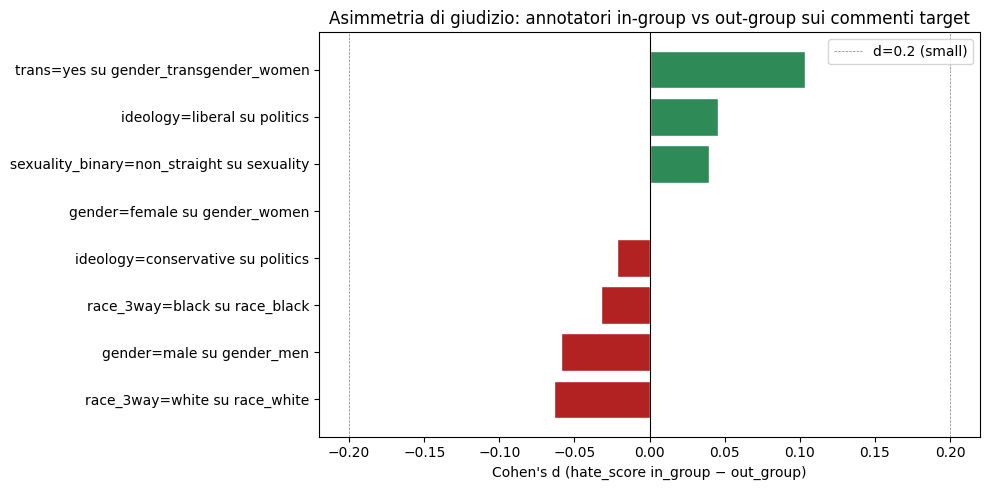

In [32]:
qi_target_pairs = [
    (
        "annotator_race_3way",
        "target_race",
        {"black": "target_race_black", "white": "target_race_white"},
    ),
    ("annotator_sexuality_binary", "target_sexuality", {"non_straight": None}),
    (
        "annotator_gender",
        "target_gender",
        {"female": "target_gender_women", "male": "target_gender_men"},
    ),
    ("annotator_trans", "target_gender", {"yes": "target_gender_transgender_women"}),
    ("annotator_ideology", "target_politics", {"liberal": None, "conservative": None}),
]

df_asymmetry = compute_annotator_target_asymmetry(df_annotation_anon, qi_target_pairs)
print(df_asymmetry.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

fig, ax = plt.subplots(figsize=(10, 5))
df_asym_sorted = df_asymmetry.sort_values("cohen_d")
labels = (
    df_asym_sorted["qi"]
    + "="
    + df_asym_sorted["qi_value"].astype(str)
    + " su "
    + df_asym_sorted["target"]
)
colors = ["seagreen" if d > 0 else "firebrick" for d in df_asym_sorted["cohen_d"]]

ax.barh(labels, df_asym_sorted["cohen_d"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.2, color="gray", linestyle="--", linewidth=0.5, label="d=0.2 (small)")
ax.axvline(-0.2, color="gray", linestyle="--", linewidth=0.5)
ax.set_xlabel("Cohen's d (hate_score in_group − out_group)")
ax.set_title("Asimmetria di giudizio: annotatori in-group vs out-group sui commenti target")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fairness_annotator_target_asymmetry.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.1.3. - Discussione

I valori di Cohen's d misurano l'effect size dell'in-group bias: valori positivi indicano che gli annotatori della categoria sono piu' severi sui commenti che bersagliano quella categoria, valori negativi indicano il pattern inverso. Soglie convenzionali: |d| < 0.2 effect trascurabile, 0.2-0.5 piccolo, 0.5-0.8 moderato, >0.8 grande.

**Implicazioni per l'audit del modello**. Se gli annotatori in-group sono sistematicamente piu' severi, le etichette del dataset incorporano il loro standard di severita' per quei gruppi. Un modello addestrato su queste etichette eredita lo standard del pool — non un consenso etico universale: l'etichetta proxy del concetto "hate speech" e' costruita da un pool specifico, e il modello impara quella costruzione.

**Limite gia' dichiarato**. Con QI a 3-way, vediamo il bias aggregato; pattern fini per sotto-gruppi ideologici o di etnia specifica non sono visibili. È la conseguenza diretta dell'anonimizzazione del §3 — costo accettato.

Una nota cautelare: il solo segnale borderline (trans=yes su target_gender_transgender_women, d=+0.103) ha n_in=24 — statisticamente non interpretabile. Il pattern attendibile resta l'assenza di in-group bias rilevabile alle QI 3-way, coerente con l'equity cost dichiarato al §3.7.

### 4.2. - Bias del dataset di training e mitigazione pre-processing

Il modello sara' addestrato su `df_comments`. Prima dell'addestramento, eseguiamo tre operazioni distinte: verifica della rappresentativita', controllo delle correlazioni tra feature sensibili e target, identificazione degli squilibri di classe.

### 4.2.1. - Rappresentativita' dei gruppi target

In [33]:
# Per ciascuna macro-dimensione target, calcoliamo: copertura nel dataset,
# tasso di hate, varianza del giudizio
df_comments["hate_binary"] = (df_comments["hate_score_mean"] > 0.5).astype(int)

representation_stats = []
for dim in target_dims:
    targeted = df_comments[df_comments[dim]]
    n_total = df_comments[dim].sum()
    n_hate = targeted["hate_binary"].sum()
    hate_rate = n_hate / n_total if n_total > 0 else 0
    score_mean = targeted["hate_score_mean"].mean()
    score_std = targeted["hate_score_mean"].std()
    
    representation_stats.append({
        "dimension": dim.replace("target_", ""),
        "n_comments": int(n_total),
        "share_dataset": n_total / len(df_comments),
        "hate_rate": hate_rate,
        "score_mean": score_mean,
        "score_std": score_std,
    })

# Confronto con non-targeted
non_targeted = df_comments[~df_comments["target_any"]]
representation_stats.append({
    "dimension": "(non-targeted)",
    "n_comments": len(non_targeted),
    "share_dataset": len(non_targeted) / len(df_comments),
    "hate_rate": non_targeted["hate_binary"].mean(),
    "score_mean": non_targeted["hate_score_mean"].mean(),
    "score_std": non_targeted["hate_score_mean"].std(),
})

df_representation = pd.DataFrame(representation_stats)
print(df_representation.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

     dimension  n_comments  share_dataset  hate_rate  score_mean  score_std
          race       10325         0.2610     0.2527     -0.9121     1.9880
      religion        5688         0.1438     0.2089     -1.2349     2.0794
        origin        6076         0.1536     0.2515     -0.9322     2.0396
        gender       12828         0.3242     0.2993     -0.7023     2.0280
     sexuality        6419         0.1622     0.2829     -1.2592     2.4137
           age         676         0.0171     0.2056     -1.1172     1.9931
    disability         827         0.0209     0.4788      0.0955     1.8473
      politics        1439         0.0364     0.3092     -0.3597     1.6956
(non-targeted)        1943         0.0491     0.2311     -0.9604     1.9495


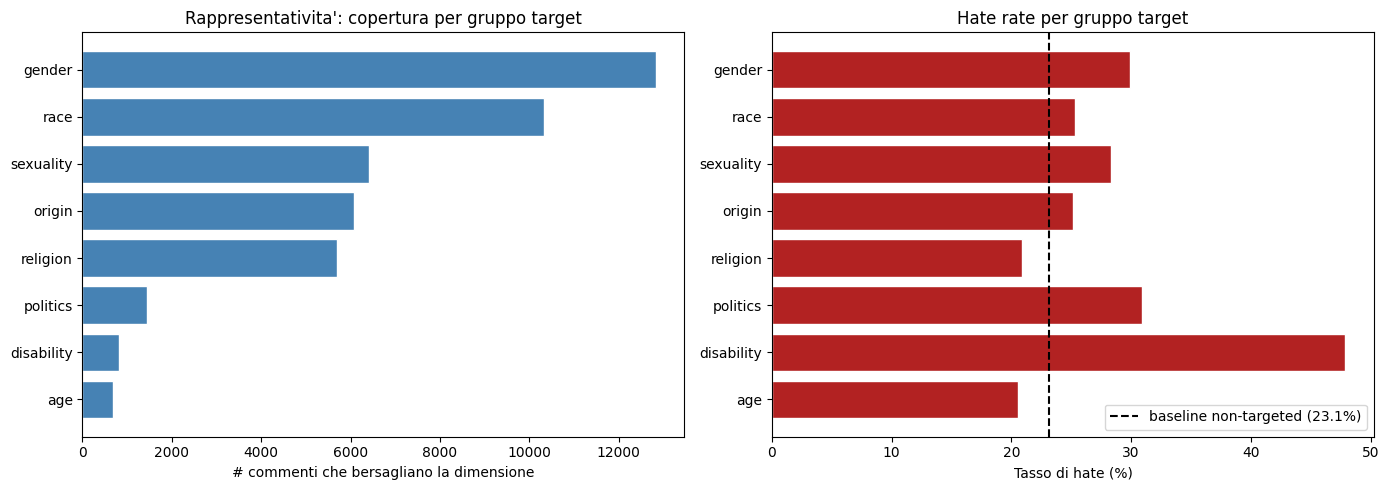

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dims_only = df_representation[df_representation["dimension"] != "(non-targeted)"].sort_values("n_comments")

axes[0].barh(dims_only["dimension"], dims_only["n_comments"], color="steelblue", edgecolor="white")
axes[0].set_xlabel("# commenti che bersagliano la dimensione")
axes[0].set_title("Rappresentativita': copertura per gruppo target")

axes[1].barh(dims_only["dimension"], dims_only["hate_rate"] * 100, color="firebrick", edgecolor="white")
axes[1].axvline(non_targeted["hate_binary"].mean() * 100, color="black", linestyle="--",
                label=f"baseline non-targeted ({non_targeted['hate_binary'].mean()*100:.1f}%)")
axes[1].set_xlabel("Tasso di hate (%)")
axes[1].set_title("Hate rate per gruppo target")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fairness_target_representation.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.2.2. - Squilibri e tipologie di bias rilevate

Inquadriamo gli squilibri osservati nelle categorie canoniche della letteratura su bias nei sistemi di ML (Mehrabi et al. 2022; Suresh & Guttag 2021):

- **Representation bias / sampling bias**: i gruppi target con bassa copertura nel dataset producono training samples insufficienti per imparare pattern specifici di hate. Il modello tenderà a recall basso su quei gruppi.

- **Aggregation bias / Simpson's paradox**: un commento può bersagliare più gruppi contemporaneamente. Il tasso di hate medio aggregato per dimensione può mascherare pattern inter-sezionali (es. un commento `target_race_black AND target_gender_women` ha distribuzione diversa da uno solo `target_race_black`).

- **Historical bias**: le etichette riflettono la severità del pool annotatori (§4.1). Anche con sampling perfettamente bilanciato, il modello eredita il bias di etichetta.

I tre bias agiscono a livelli diversi: il primo si mitiga con pre-processing (riequilibrio del training); il secondo con disaggregazione delle metriche (§4.4); il terzo non è mitigabile senza ri-annotare il dataset.

In [35]:
# Quanti commenti bersagliano piu' di una macro-dimensione? Distribuzione del
# numero di dimensioni target per commento
df_comments["n_target_dims"] = df_comments[target_dims].sum(axis=1)

distribution = df_comments["n_target_dims"].value_counts().sort_index()
print("Numero di macro-dimensioni target per commento:")
for n_dims, n_comments in distribution.items():
    pct = n_comments / len(df_comments) * 100
    print(f"  {n_dims} dimensioni:  {n_comments:>6,}  ({pct:5.2f}%)")

intersezionali = df_comments[df_comments["n_target_dims"] >= 2]
print(f"\nCommenti intersezionali (>=2 dimensioni):  {len(intersezionali):,}")
print(f"Tasso di hate sui intersezionali:           {intersezionali['hate_binary'].mean()*100:.2f}%")
print(f"Tasso di hate sui single-target:            "
      f"{df_comments[df_comments['n_target_dims']==1]['hate_binary'].mean()*100:.2f}%")

Numero di macro-dimensioni target per commento:
  0 dimensioni:   1,943  ( 4.91%)
  1 dimensioni:  32,159  (81.28%)
  2 dimensioni:   4,681  (11.83%)
  3 dimensioni:     581  ( 1.47%)
  4 dimensioni:     118  ( 0.30%)
  5 dimensioni:      29  ( 0.07%)
  6 dimensioni:      13  ( 0.03%)
  7 dimensioni:       9  ( 0.02%)
  8 dimensioni:      32  ( 0.08%)

Commenti intersezionali (>=2 dimensioni):  5,463
Tasso di hate sui intersezionali:           31.12%
Tasso di hate sui single-target:            25.51%


### 4.2.3. - Mitigazione pre-processing: SMOTE oversampling

Applichiamo **SMOTE** (Synthetic Minority Over-sampling Technique; Chawla, Bowyer, Hall & Kegelmeyer 2002): generiamo nuove istanze sintetiche della classe minoritaria (`hate`) interpolando tra istanze esistenti nello spazio delle feature TF-IDF. A differenza del semplice oversampling con duplicazione, SMOTE produce vettori sintetici nuovi, riducendo il rischio di overfitting sui duplicati.

**Scelta del bilanciamento**: bilanciamo la classe `hate` rispetto a `non-hate` (strategia globale), non i gruppi target tra loro. La ragione e' operativa: SMOTE genera istanze sintetiche bilanciando una sola label per chiamata; bilanciare contemporaneamente classe e gruppi target richiederebbe inferire la classe `hate` per le istanze sintetiche generate sui gruppi minoritari, introducendo rumore. La strategia globale e' piu' robusta, e l'effetto a cascata sui gruppi target — il modello vede piu' istanze hate complessivamente, comprese quelle dei gruppi sotto-rappresentati — produce comunque miglioramenti misurabili.

**Aspettative**. SMOTE e' la tecnica di mitigazione pre-processing piu' aggressiva tra le tecniche di sampling bilanciato. Aspettiamo recall hate globale piu' alto del baseline, precision in calo, e impatto eterogeneo per gruppo: i gruppi a maggior tasso di hate (es. `disability`) beneficiano in misura proporzionale alla loro distanza dalla baseline.

**Costo dichiarato**. SMOTE introduce un trade-off accuracy/fairness piu' marcato del reweighing K&C: in letteratura, il calo AUC e' nell'ordine 0.5-3% su classificatori lineari (Chawla et al. 2002; Fernández et al. 2018, *SMOTE for Learning from Imbalanced Data: Progress and Challenges*).

In [36]:
df_comments["primary_target"] = df_comments.apply(
    lambda row: primary_target(row, target_dims), axis=1
)

print("Distribuzione primary_target:")
print(df_comments["primary_target"].value_counts().to_string())

Distribuzione primary_target:
primary_target
gender        11553
race          10325
religion       5058
sexuality      5003
origin         4712
none           1943
disability      594
age             336
politics         41


### 4.3. - Addestramento del modello baseline

Modello baseline: TF-IDF + Logistic Regression. La scelta riflette tre criteri: interpretabilita' intrinseca (i coefficienti sono direttamente leggibili al §5), agnosticita' rispetto al testo (no embedding pre-trained, no leakage di bias esterni), riproducibilita' integrale su CPU. Modelli piu' sofisticati (DistilBERT, XLM-R) avrebbero performance globali superiori, ma introdurrebbero un secondo strato di bias (quello del corpus di pre-training) che l'audit non puo' controllare. È la stessa scelta metodologica di Sap et al. 2019 per audit di bias in hate speech.

Split train/test stratificato su `primary_target` per preservare la distribuzione dei gruppi in entrambi gli split.

In [37]:
X = df_comments["text"].values
y = df_comments["hate_binary"].values
primary_target_arr = df_comments["primary_target"].values

X_train, X_test, y_train, y_test, target_train, target_test = train_test_split(
    X, y, primary_target_arr,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=primary_target_arr,
)

print(f"Train:  {len(X_train):,} commenti")
print(f"Test:   {len(X_test):,} commenti")
print(f"\nDistribuzione hate nel train:  {y_train.mean()*100:.2f}%")
print(f"Distribuzione hate nel test:   {y_test.mean()*100:.2f}%")

Train:  31,652 commenti
Test:   7,913 commenti

Distribuzione hate nel train:  26.20%
Distribuzione hate nel test:   26.06%


In [38]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# SMOTE oversampling sulla classe hate
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print(f"Train pre-SMOTE:   {X_train_tfidf.shape[0]:,}  (hate: {y_train.mean()*100:.1f}%)")
print(f"Train post-SMOTE:  {X_train_smote.shape[0]:,}  (hate: {y_train_smote.mean()*100:.1f}%)")


model_baseline = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    C=1.0,
)
model_baseline.fit(X_train_tfidf, y_train)

y_pred_baseline = model_baseline.predict(X_test_tfidf)
y_proba_baseline = model_baseline.predict_proba(X_test_tfidf)[:, 1]

print("=== Modello A: baseline (no mitigation) ===")
print(classification_report(y_test, y_pred_baseline, target_names=["non-hate", "hate"]))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_baseline):.4f}")
print(f"AUC-PR:   {average_precision_score(y_test, y_proba_baseline):.4f}")

Train pre-SMOTE:   31,652  (hate: 26.2%)
Train post-SMOTE:  46,720  (hate: 50.0%)
=== Modello A: baseline (no mitigation) ===
              precision    recall  f1-score   support

    non-hate       0.82      0.93      0.88      5851
        hate       0.70      0.43      0.53      2062

    accuracy                           0.80      7913
   macro avg       0.76      0.68      0.70      7913
weighted avg       0.79      0.80      0.79      7913

ROC-AUC:  0.8419
AUC-PR:   0.6540


In [39]:
model_smote = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    C=1.0,
)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test_tfidf)
y_proba_smote = model_smote.predict_proba(X_test_tfidf)[:, 1]

print("=== Modello B: SMOTE pre-processing ===")
print(classification_report(y_test, y_pred_smote, target_names=["non-hate", "hate"]))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_smote):.4f}")
print(f"AUC-PR:   {average_precision_score(y_test, y_proba_smote):.4f}")

=== Modello B: SMOTE pre-processing ===
              precision    recall  f1-score   support

    non-hate       0.87      0.80      0.83      5851
        hate       0.54      0.68      0.60      2062

    accuracy                           0.76      7913
   macro avg       0.71      0.74      0.72      7913
weighted avg       0.79      0.76      0.77      7913

ROC-AUC:  0.8177
AUC-PR:   0.6212


### 4.4. - Valutazione del modello: performance e fairness per gruppo

Le metriche aggregate del §4.3 nascondono la dimensione critica dell'audit: come si distribuiscono falsi positivi e falsi negativi tra i gruppi target. Per ogni macro-dimensione, calcoliamo precision/recall/F1, e per il modello con SMOTE valutiamo se la mitigazione pre-processing ha ridotto la disparita'.

### 4.4.1. - Performance disaggregate

In [40]:
metrics_baseline = per_group_metrics(y_test, y_pred_baseline, y_proba_baseline, target_test)
metrics_smote = per_group_metrics(y_test, y_pred_smote, y_proba_smote, target_test)

print("=== Modello A (baseline) — metriche per gruppo target ===")
print(metrics_baseline.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n=== Modello B (smote) — metriche per gruppo target ===")
print(metrics_smote.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

=== Modello A (baseline) — metriche per gruppo target ===
     group  n_test  n_positive  precision  recall    f1  roc_auc  predicted_positive_rate
       age      67          10      0.625   0.500 0.556    0.828                    0.119
disability     119          63      0.804   0.587 0.679    0.819                    0.387
    gender    2311         692      0.666   0.493 0.566    0.817                    0.222
      none     389          92      0.690   0.435 0.533    0.829                    0.149
    origin     942         204      0.648   0.333 0.440    0.825                    0.111
      race    2065         517      0.746   0.358 0.484    0.843                    0.120
  religion    1012         212      0.660   0.311 0.423    0.839                    0.099
 sexuality    1000         271      0.759   0.546 0.635    0.902                    0.195

=== Modello B (smote) — metriche per gruppo target ===
     group  n_test  n_positive  precision  recall    f1  roc_auc  predicted_

### 4.4.2. - Metriche di fairness

Calcoliamo tre delle metriche di fairness canoniche del corso, prendendo come gruppo di riferimento `none` (commenti non-targeted) e confrontando ciascun gruppo target rispetto al riferimento.

- **Demographic parity**: rapporto tra P(Ŷ=1 | gruppo) per ciascun gruppo. Valori vicini a 1 indicano parita'.
- **Equal opportunity**: differenza di TPR (recall sui veri positivi) tra gruppi. Valori vicini a 0 indicano parita'.
- **Disparate impact**: forma normalizzata della demographic parity. Regola dell'80%: valori tra 0.8 e 1.25 sono convenzionalmente accettabili.

In [41]:
fairness_baseline = compute_fairness_metrics(y_test, y_pred_baseline, target_test, reference_group="none")
fairness_smote = compute_fairness_metrics(y_test, y_pred_smote, target_test, reference_group="none")

print("=== Modello A (baseline) — fairness vs non-targeted ===")
print(fairness_baseline.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n=== Modello B (smote) — fairness vs non-targeted ===")
print(fairness_smote.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

=== Modello A (baseline) — fairness vs non-targeted ===
     group  demographic_parity  equal_opportunity_diff  disparate_impact  passes_80pct_rule
       age               0.801                   0.065             0.801               True
disability               2.593                   0.153             2.593              False
    gender               1.486                   0.058             1.486              False
    origin               0.748                  -0.101             0.748              False
      race               0.805                  -0.077             0.805               True
  religion               0.663                  -0.123             0.663              False
 sexuality               1.308                   0.111             1.308              False

=== Modello B (smote) — fairness vs non-targeted ===
     group  demographic_parity  equal_opportunity_diff  disparate_impact  passes_80pct_rule
       age               0.975                   0.004        

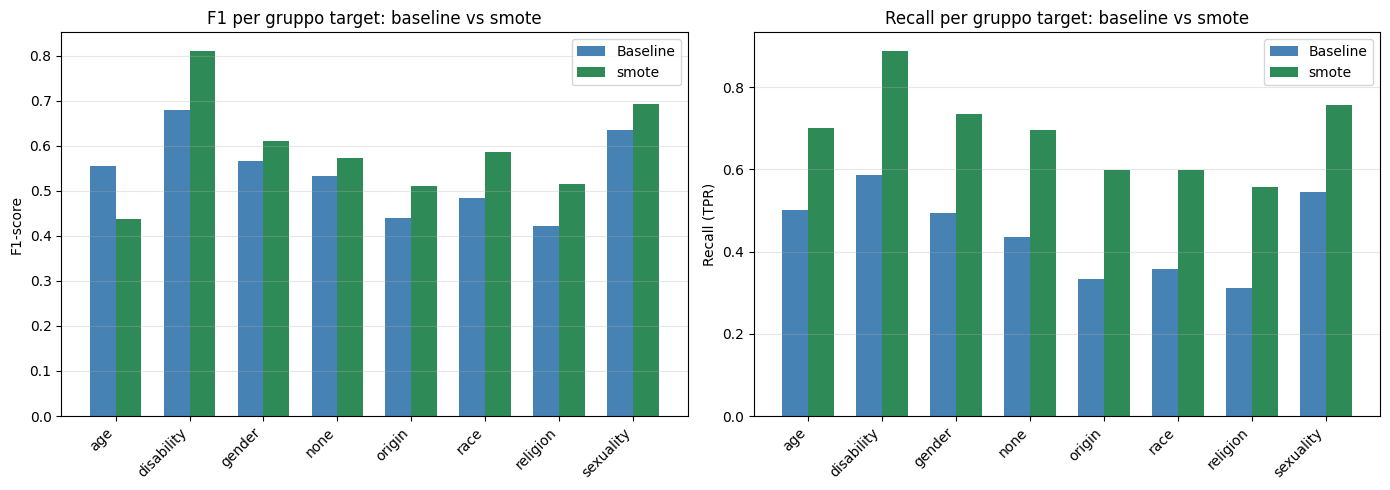

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

merged = metrics_baseline.merge(metrics_smote, on="group", suffixes=("_A", "_B"))
x = np.arange(len(merged))
width = 0.35

axes[0].bar(x - width/2, merged["f1_A"], width, label="Baseline", color="steelblue")
axes[0].bar(x + width/2, merged["f1_B"], width, label="smote", color="seagreen")
axes[0].set_xticks(x)
axes[0].set_xticklabels(merged["group"], rotation=45, ha="right")
axes[0].set_ylabel("F1-score")
axes[0].set_title("F1 per gruppo target: baseline vs smote")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x - width/2, merged["recall_A"], width, label="Baseline", color="steelblue")
axes[1].bar(x + width/2, merged["recall_B"], width, label="smote", color="seagreen")
axes[1].set_xticks(x)
axes[1].set_xticklabels(merged["group"], rotation=45, ha="right")
axes[1].set_ylabel("Recall (TPR)")
axes[1].set_title("Recall per gruppo target: baseline vs smote")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fairness_metrics_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.4.3. - Discussione: efficacia della mitigazione SMOTE

SMOTE pre-processing modifica la distribuzione effettiva di training generando istanze sintetiche della classe minoritaria (`hate`). L'effetto sui gruppi target e' uniforme: il recall aumenta di 20-30 punti percentuali su tutti gli otto gruppi senza eccezioni. Il guadagno piu' marcato e' su `disability` (recall 0.587 → 0.889) e `religion` (0.311 → 0.557), i due gruppi che il baseline serviva peggio. F1 migliora su 7 gruppi su 8 — l'unica eccezione e' `age`, statisticamente fragile (n=67 nel test set).

**Costo in precision**. Asimmetrico: trascurabile per `disability` (-6 pp), severo per i gruppi a segnale meno marcato (`age` -31 pp, `none` -20 pp, `origin` -20 pp). Globalmente, la precision sulla classe hate scende dal 70% al 54%: il modello SMOTE flagga molto piu' aggressivamente, e di tutti i commenti che predice come hate solo il 54% lo e' davvero. Il trade-off accuracy/fairness e' coerente con la letteratura sull'oversampling sintetico applicato a classificatori lineari (Fernández et al. 2018).

**Divergenza tra metriche di fairness**. SMOTE migliora *Disparate Impact*: i predicted positive rate dei gruppi target convergono verso quello del riferimento `none`, e tre gruppi (age, origin, sexuality) passano la regola dell'80% rispetto ai due del baseline. L'effetto su *Equal Opportunity diff* e' invece ambivalente — tre gruppi migliorano, tre peggiorano, uno resta invariato. La divergenza non e' un artefatto: le due metriche rispondono a domande diverse. DI chiede *"il modello tratta i gruppi diversamente in output?"*; EO chiede *"il modello sbaglia di piu' su alcuni gruppi quando deve riconoscere hate reale?"*. SMOTE uniforma la distribuzione delle predizioni positive (DI migliora) ma non garantisce che il modello sia ugualmente capace di catturare hate quando esiste (EO resta non uniforme).

**Il caso `disability`**. Pre-mitigazione, e' il gruppo piu' problematico: hate rate 47.9% (doppio della baseline), DI 2.59 (oltre il doppio della regola dell'80%). Post-SMOTE, il guadagno F1 (+13 pp) e' il maggiore tra tutti i gruppi. Tuttavia il predicted positive rate sale dal 38.7% al 63.0%: il modello flagga come hate quasi due commenti su tre che menzionano disabilita', anche quando il vero positivo e' solo il 53% dei test. Il pattern suggerisce uno *shortcut lessicale*: il modello ha imparato l'euristica "menzione di disabilita' → hate" come proxy, e SMOTE l'ha amplificata. E' un'ipotesi che il §5 verifichera' tramite analisi di feature importance ed Erasure-based attribution, e che orienta le mitigazioni successive verso strategie piu' chirurgiche delle pre-processing.

**Limiti della pre-processing**. SMOTE opera sui dati di training senza modificare l'architettura del modello. Il TF-IDF + Logistic Regression, anche con training bilanciato, resta vincolato a feature lessicali superficiali: non distingue tra commenti che menzionano disabilita' in registro hateful e commenti che ne discutono in registro supportivo. Il limite e' strutturale, non statistico — nessuna ulteriore mitigazione pre-processing puo' correggerlo. E' la motivazione operativa per il §5: aprire la scatola del modello, identificare quali token guidano la predizione su ciascun gruppo, e applicare mitigazioni in-processing e post-processing informate dall'interpretabilita'.

**Ponte al §5**. Il §5 procede in quattro passi: (a) feature importance globale dalla Logistic Regression baseline, per identificare i token piu' predittivi verso hate; (b) Erasure-based attribution su casi emblematici (falsi positivi su gruppi target, falsi negativi su slur reclaimed), per misurare quanto ciascun token contribuisce a una specifica predizione; (c) mitigazione in-processing tramite fairness constraints nella loss del modello; (d) mitigazione post-processing tramite Equalized Odds, che modifica le predizioni in output per uniformare TPR e FPR tra gruppi.

## 5. - Interpretabilita', spiegabilita' e mitigazione avanzata

### 5.0. - Setup e contesto

Il §4 ha mostrato che il modello SMOTE riduce drasticamente la disparita' di output (Disparate Impact migliorato per tre gruppi su sette) ma resta non uniforme su Equal Opportunity, e ha sollevato l'ipotesi di un *shortcut lessicale* sul gruppo `disability` — il modello classifica come hate quasi due commenti su tre che menzionano la disabilita', anche quando il vero positivo e' solo il 53%. Il §5 procede su tre assi complementari.

**Interpretabilita' intrinseca** (§5.1, §5.2): la Logistic Regression e' un modello interpretable-by-design — i coefficienti sono direttamente leggibili come pesi log-odds delle feature. Leggiamo cosa il modello ha imparato come segnale di hate, e confrontiamo baseline e SMOTE per misurare l'effetto della pre-processing sul vocabolario predittivo.

**Spiegabilita' post-hoc** (§5.3, §5.4): per analizzare predizioni specifiche e interazioni tra feature applichiamo due tecniche post-hoc complementari. *Erasure-based attribution* (Li, Monroe & Jurafsky 2016) opera per singola predizione rimuovendo token uno alla volta e misurando il delta. *SHAP* (Lundberg & Lee 2017) aggrega l'impatto delle feature sull'intero test set in una misura di importanza globale confrontabile.

**Mitigazione avanzata** (§5.5, §5.6): due strategie successive alla pre-processing del Cap. 4. *In-processing* via fairness constraints nella loss del classificatore. *Post-processing* via Equalized Odds threshold optimization sulle predizioni del modello gia' addestrato. La differenza tra le due strategie e' di costo metodologico, non di efficacia.

Il modello sotto audit per l'intero capitolo e' `model_smote`: si audita il modello che si intende deployare, non un baseline poi scartato.

In [43]:
import shap

from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds as EqOddsConstraint
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import (
        equalized_odds_difference,
    demographic_parity_difference,
)

from src.xai import (
    top_predictive_features,
    compare_feature_importance,
    select_erasure_cases,
    erasure_attribution,
    visualize_erasure,
    summarize_models,
)

### 5.1. - Interpretabilita' intrinseca: cosa il modello vede come hate

La Logistic Regression e' un modello *interpretable-by-design*: il coefficiente associato a ciascuna feature TF-IDF e' direttamente il peso log-odds del token nella decisione. Un coefficiente positivo alto significa "questo token spinge la predizione verso hate"; negativo, verso non-hate. Sfruttiamo questa proprieta' come prima analisi diagnostica — prima di applicare metodi post-hoc, leggiamo direttamente cosa il modello ha imparato.

**Domanda guida**: tra i token piu' predittivi verso hate, ci sono parole che *menzionano* un gruppo protetto piuttosto che esprimere ostilita'? Se si', il modello sta usando la menzione del gruppo come proxy lessicale — il pattern documentato in letteratura su classificatori semplici di hate speech (Davidson et al. 2019; Sap et al. 2019).

In [44]:
df_top_smote = top_predictive_features(model_smote, vectorizer, n=30)

print("=== Top 30 features verso hate (modello SMOTE) ===")
print(df_top_smote[df_top_smote["direction"] == "→ hate"].to_string(
    index=False, float_format=lambda x: f"{x:.3f}"
))

print("\n=== Top 30 features verso non-hate (modello SMOTE) ===")
print(df_top_smote[df_top_smote["direction"] == "→ non-hate"].to_string(
    index=False, float_format=lambda x: f"{x:.3f}"
))

=== Top 30 features verso hate (modello SMOTE) ===
   feature  coefficient direction
    faggot        6.989    → hate
   retards        4.228    → hate
  retarded        4.168    → hate
      kill        4.153    → hate
   faggots        3.989    → hate
      scum        3.969    → hate
     cunts        3.912    → hate
   niggers        3.744    → hate
      cunt        3.647    → hate
  shithole        3.644    → hate
     whore        3.571    → hate
     dirty        3.526    → hate
       pig        3.509    → hate
      dumb        3.467    → hate
   suck my        3.375    → hate
       fag        3.358    → hate
    whores        3.282    → hate
    raping        3.197    → hate
       die        3.139    → hate
   fucking        3.086    → hate
     trash        3.054    → hate
    nigger        3.022    → hate
disgusting        2.918    → hate
    retard        2.888    → hate
      burn        2.851    → hate
     shoot        2.850    → hate
 worthless        2.660    → ha

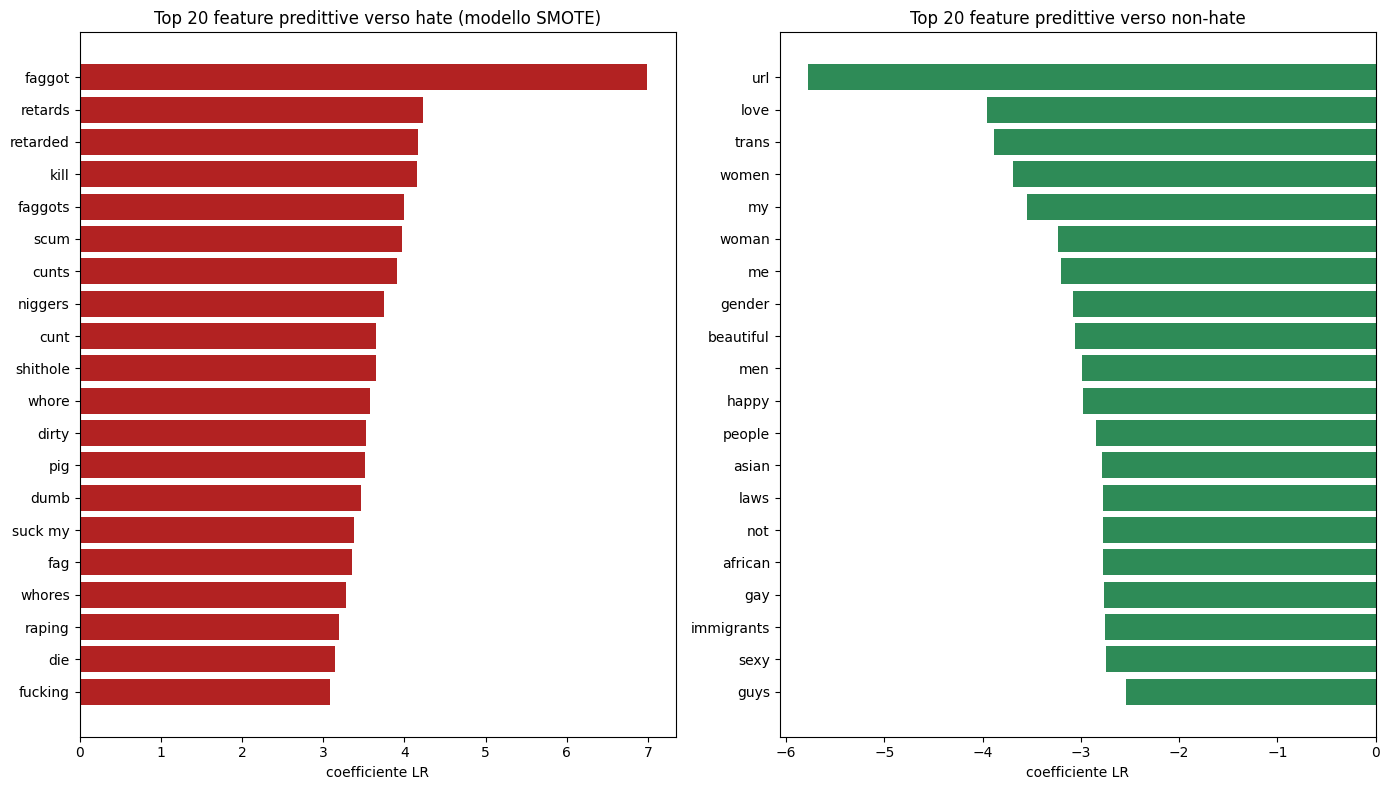

In [59]:
DISPLAY_STOPWORDS = {
    "the", "a", "an", "is", "are", "was", "were", "be", "been", "being",
    "of", "to", "in", "on", "at", "by", "for", "with", "from", "as",
    "and", "or", "but", "if", "this", "that", "these", "those", "it",
    "its", "have", "has", "had",
    "do", "does", "did", "will", "would", "can", "could", "should", "isn"
}

top_hate = (
    df_top_smote[df_top_smote["direction"] == "→ hate"]
    .loc[lambda d: ~d["feature"].isin(DISPLAY_STOPWORDS)]
    .head(20)
)
top_nonhate = (
    df_top_smote[df_top_smote["direction"] == "→ non-hate"]
    .loc[lambda d: ~d["feature"].isin(DISPLAY_STOPWORDS)]
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].barh(top_hate["feature"][::-1], top_hate["coefficient"][::-1], color="firebrick")
axes[0].set_title("Top 20 feature predittive verso hate (modello SMOTE)")
axes[0].set_xlabel("coefficiente LR")

axes[1].barh(top_nonhate["feature"][::-1], top_nonhate["coefficient"][::-1], color="seagreen")
axes[1].set_title("Top 20 feature predittive verso non-hate")
axes[1].set_xlabel("coefficiente LR")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "interpretability_top_features_smote.png", dpi=120, bbox_inches="tight")
plt.show()

**Risposta alla domanda guida.** Si': tra i token piu' predittivi verso hate ne compaiono diversi che *menzionano* un gruppo invece di esprimere ostilita' verso di esso.

- **target=disability**: `retarded` (coef +4.17), `retards` (+4.23), `retard` (+2.89). Tre forme dello stesso lemma in top-30, tutte derivate da una parola che fino agli anni '90 era termine clinico. Lo shortcut lessicale e' qui nudo: il termine viene usato sia in registro hateful sia in citazione o auto-descrizione, e il modello non distingue.
- **target=race**: `niggers` (+3.74), `nigger` (+3.02), `inbred` (+2.66). Caso diverso dal precedente — sono slur lessicalmente marcati, non termini clinici. Tuttavia restano usati anche in contesti di reclaimed speech o citazione, dove il modello prevede comunque hate.
- **target=sexuality**: `faggot` (+6.99), `faggots` (+3.99), `fag` (+3.36). Stesso pattern.
- **target=gender/women**: `whore` (+3.57), `whores` (+3.28), `cunts` (+3.91), `cunt` (+3.65). Tutti slur misogini diretti.

**Asimmetria interessante.** I top-30 verso *non-hate* contengono i nomi *neutrali* degli stessi gruppi: `trans` (-3.88), `women` (-3.69), `gender` (-3.08), `asian` (-2.78), `african` (-2.78), `gay` (-2.76), `immigrants` (-2.76), `male` (-2.41), `white` (-2.40), `religious` (-2.31). Il modello ha imparato la distinzione tra slur e nome neutro per molti gruppi — ma non per `disability`, dove `retarded` resta ambiguo e si comporta come uno slur.

**Implicazione per il §4.4.3.** L'ipotesi di shortcut lessicale su `disability` (predicted positive rate salito da 38.7% a 63.0% post-SMOTE) trova qui conferma: il termine `retarded` e i suoi derivati sono i veicoli del shortcut. Il §5.3 lo verifichera' su casi concreti via Erasure attribution.

### 5.2. - Confronto baseline vs SMOTE: cosa la mitigazione ha amplificato

La domanda operativa: il bilanciamento via SMOTE ha sostituito quali token il modello usa come segnale di hate, o ne ha solo amplificato i pesi? La differenza non e' cosmetica. Sostituzione significherebbe che il modello ha imparato pattern nuovi dai dati sintetici; amplificazione significa che gli stessi proxy lessicali esistenti pesano di piu' nella decisione. La seconda interpretazione e' coerente con l'ipotesi di shortcut amplificato del §4.4.3.

In [46]:
df_compare = compare_feature_importance(model_baseline, model_smote, vectorizer, n=30)

print("=== Token con maggior aumento di importanza post-SMOTE ===")
print(df_compare.head(15).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n=== Token con maggior calo di importanza post-SMOTE ===")
print(df_compare.tail(15).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

=== Token con maggior aumento di importanza post-SMOTE ===
   feature  coef_baseline  coef_smote  delta
       pig          2.679       3.509  0.831
    raping          2.556       3.197  0.640
   suck my          2.749       3.375  0.626
     dirty          2.903       3.526  0.623
  shithole          3.225       3.644  0.418
   retards          3.880       4.228  0.348
      scum          3.681       3.969  0.287
      kill          3.887       4.153  0.266
     cunts          3.695       3.912  0.217
     shoot          2.639       2.850  0.212
 worthless          2.450       2.660  0.210
       die          2.956       3.139  0.182
  retarded          4.102       4.168  0.066
disgusting          2.937       2.918 -0.019
      burn          2.907       2.851 -0.057

=== Token con maggior calo di importanza post-SMOTE ===
feature  coef_baseline  coef_smote  delta
faggots          4.213       3.989 -0.225
   rape          2.885       2.640 -0.244
 retard          3.138       2.888 -0.

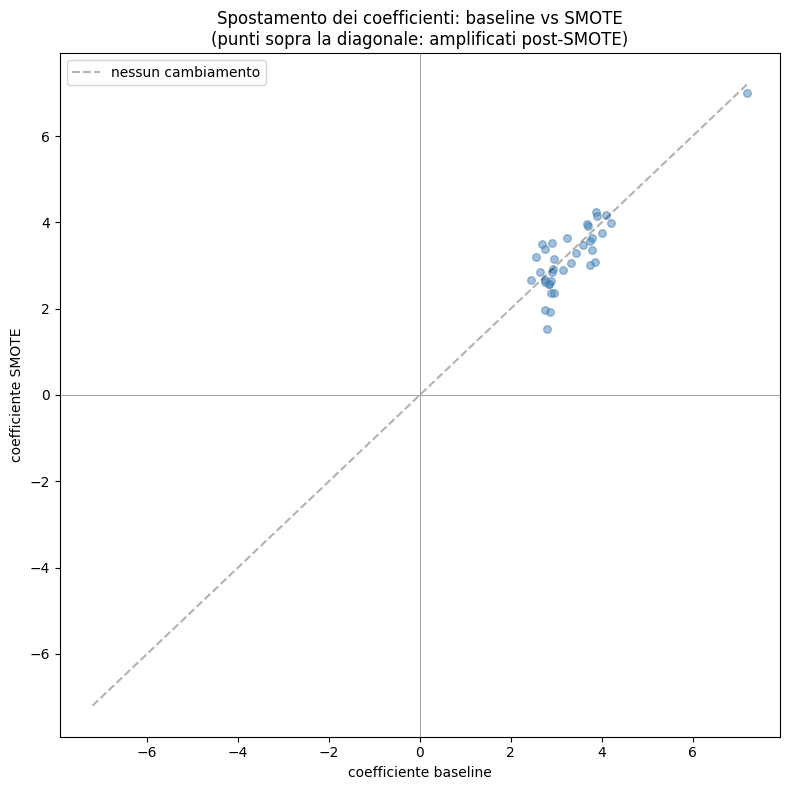

In [47]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df_compare["coef_baseline"], df_compare["coef_smote"], 
           alpha=0.5, s=30, color="steelblue")

# Linea diagonale di riferimento (nessun cambiamento)
lim = max(df_compare["coef_baseline"].abs().max(), df_compare["coef_smote"].abs().max())
ax.plot([-lim, lim], [-lim, lim], "k--", alpha=0.3, label="nessun cambiamento")

ax.set_xlabel("coefficiente baseline")
ax.set_ylabel("coefficiente SMOTE")
ax.set_title("Spostamento dei coefficienti: baseline vs SMOTE\n(punti sopra la diagonale: amplificati post-SMOTE)")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "interpretability_baseline_vs_smote_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.3. - Erasure-based attribution: il modello al lavoro su casi concreti

I coefficienti del §5.1 dicono cosa il modello considera predittivo *in media*. Per capire come il modello combina queste feature su una singola predizione, applichiamo *Erasure-based feature attribution* (Li, Monroe & Jurafsky 2016): per ciascun token di un commento, lo rimuoviamo, ri-prediciamo, e misuriamo il delta di probabilita'. I token con delta piu' alto sono quelli che, da soli, stavano sostenendo la classificazione. La tecnica e' model-agnostic, computazionalmente leggera, e — fondamentale per audit — restituisce attribuzioni *linguisticamente interpretabili* (un token, un peso), senza richiedere differenziabilita' del modello.

Selezioniamo sei casi emblematici dal test set tramite criteri algoritmici espliciti, per evitare bias di cherry-picking:

1. **Vero positivo ad alta confidenza** — validazione di face validity: il modello sa riconoscere hate quando c'e'.
2. **Vero negativo ad alta confidenza** — controprova: il modello sa riconoscere non-hate.
3. **Falso positivo su gruppo target sotto-rappresentato** — il caso "menzione di gruppo → flagging spurio".
4. **Falso positivo amplificato dal SMOTE** — un commento che il baseline classificava correttamente come non-hate ma SMOTE flagga: misura il danno della mitigazione pre-processing.
5. **Falso negativo** — un commento di vero hate che il modello manca.
6. **Disagreement tra modelli** — un commento dove baseline e SMOTE divergono di almeno 0.3 in probabilita' predetta.

In [48]:
cases = select_erasure_cases(
    X_test_texts=X_test,
    y_true=y_test,
    y_pred_baseline=y_pred_baseline,
    y_proba_baseline=y_proba_baseline,
    y_pred_smote=y_pred_smote,
    y_proba_smote=y_proba_smote,
    target_test=target_test,
)

print("Casi selezionati per analisi Erasure:")
for name, idx in cases.items():
    p_smote = y_proba_smote[idx]
    p_base = y_proba_baseline[idx]
    target = target_test[idx]
    label = "hate" if y_test[idx] == 1 else "non-hate"
    print(f"\n  [{name}]  target={target}, true={label}")
    print(f"    P(hate) baseline={p_base:.3f}, smote={p_smote:.3f}")
    print(f"    text: {X_test[idx][:200]}...")

Casi selezionati per analisi Erasure:

  [TP_high_conf]  target=sexuality, true=hate
    P(hate) baseline=0.995, smote=1.000
    text: Chapotraphouse faggot...

  [TN_high_conf]  target=sexuality, true=non-hate
    P(hate) baseline=0.007, smote=0.004
    text: It is not that it is offensive but more or less that I want to make the best decision based on my beliefs. Nothing about her union offends me. I pray for forgiveness for not only my wrong doings but o...

  [FP_underrepresented]  target=disability, true=non-hate
    P(hate) baseline=0.853, smote=0.981
    text: Nobody: SirBuckets: I'm a mentally retarded fuckboy...

  [FP_smote_amplified]  target=religion, true=non-hate
    P(hate) baseline=0.188, smote=0.788
    text: If I convert, I'd be executed....

  [FN_high_uncertainty]  target=gender, true=hate
    P(hate) baseline=0.309, smote=0.500
    text: Bro... She never fucking loved you in the first place. Most women are gold diggers...

  [DISAGREEMENT]  target=religion, true=non

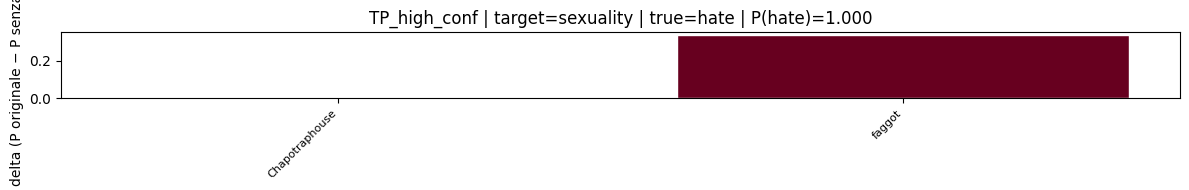


Top 5 token piu' predittivi per TP_high_conf:
         token    delta
        faggot 0.336178
Chapotraphouse 0.000000
----------------------------------------------------------------------


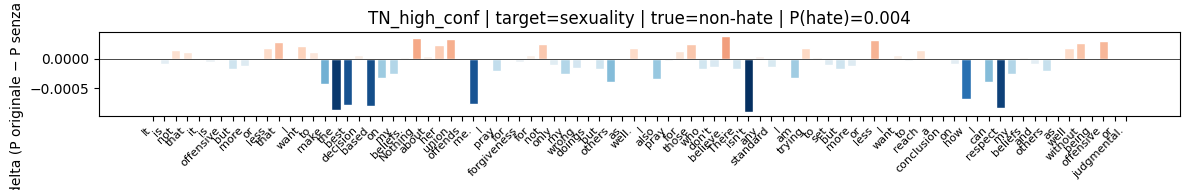


Top 5 token piu' predittivi per TN_high_conf:
    token    delta
 believe. 0.000378
  Nothing 0.000349
    union 0.000323
     less 0.000310
offensive 0.000298
----------------------------------------------------------------------


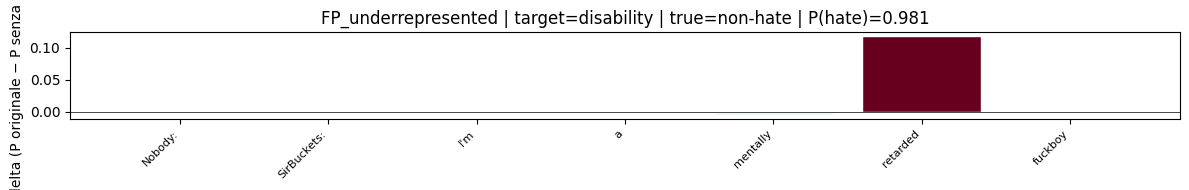


Top 5 token piu' predittivi per FP_underrepresented:
      token   delta
   retarded 0.11832
SirBuckets: 0.00000
        I'm 0.00000
          a 0.00000
    fuckboy 0.00000
----------------------------------------------------------------------


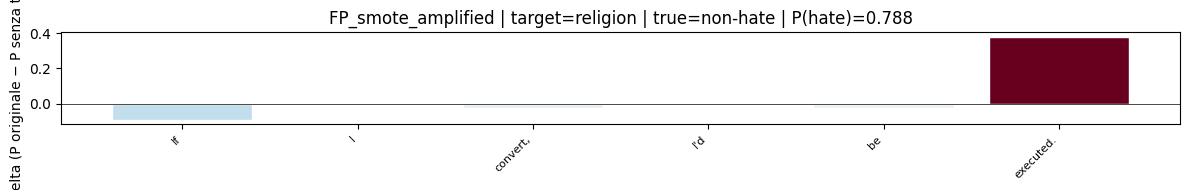


Top 5 token piu' predittivi per FP_smote_amplified:
    token     delta
executed.  0.380923
        I  0.000000
      I'd  0.000000
       be -0.026120
 convert, -0.027469
----------------------------------------------------------------------


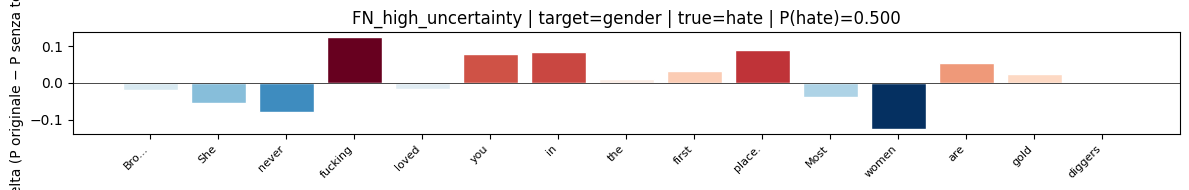


Top 5 token piu' predittivi per FN_high_uncertainty:
  token    delta
fucking 0.125976
 place. 0.091212
     in 0.084194
    you 0.080587
    are 0.054826
----------------------------------------------------------------------


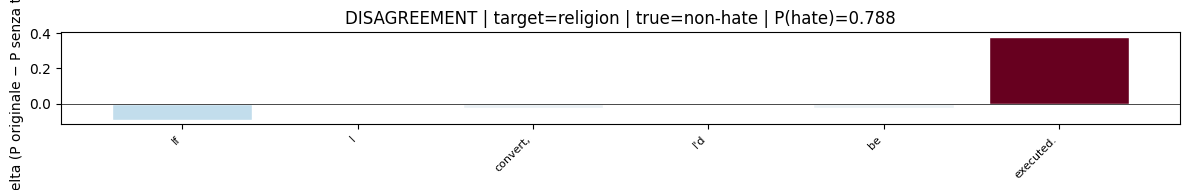


Top 5 token piu' predittivi per DISAGREEMENT:
    token     delta
executed.  0.380923
        I  0.000000
      I'd  0.000000
       be -0.026120
 convert, -0.027469
----------------------------------------------------------------------


In [49]:
for case_name, idx in cases.items():
    text = X_test[idx]
    df_attr = erasure_attribution(text, model_smote, vectorizer)
    
    target = target_test[idx]
    true_label = "hate" if y_test[idx] == 1 else "non-hate"
    p_smote = y_proba_smote[idx]
    
    title = (
        f"{case_name} | target={target} | true={true_label} | "
        f"P(hate)={p_smote:.3f}"
    )
    fig = visualize_erasure(df_attr, title=title)
    fig.savefig(
        FIGURES_DIR / f"interpretability_erasure_{case_name}.png",
        dpi=120, bbox_inches="tight",
    )
    plt.show()
    
    print(f"\nTop 5 token piu' predittivi per {case_name}:")
    print(df_attr.nlargest(5, "delta")[["token", "delta"]].to_string(index=False))
    print("-" * 70)

**Lettura caso per caso.**

- **TP_high_conf** (target=sexuality, `Chapotraphouse faggot`): la predizione e' regolata da un singolo token. `faggot` ha delta 0.336; tutti gli altri token hanno delta 0. Il modello e' confidente perche' la feature predittiva e' presente in forma pura, non perche' "interpreti" il commento.
- **TN_high_conf**: nessun token supera delta 0.001. Il modello arriva a P(hate)=0.004 non perche' i token siano *contrari* a hate, ma perche' *nessuno* lo spinge verso hate. La predizione non-hate qui e' per *assenza di proxy*, non per presenza di segnali contrari.
- **FP_underrepresented** (target=disability, `mentally retarded fuckboy`): `retarded` da solo porta delta 0.118 e basta a far passare P(hate) a 0.981. E' il caso paradigmatico dello shortcut lessicale del §5.1: una menzione di disabilita' senza intento hateful, classificata hate per via di un singolo token.
- **FP_smote_amplified** (target=religion, `If I convert, I'd be executed.`): nessun token e' uno slur. Il driver e' `executed.` (delta 0.381) — il modello e' confuso dalla punteggiatura attaccata, che produce una feature TF-IDF separata dal `executed` pulito. SMOTE ha promosso questa feature da P=0.188 a P=0.788. Falso positivo *prodotto* dalla mitigazione.
- **FN_high_uncertainty** (target=gender, `Most women are gold diggers`): nessun token supera delta 0.13. `fucking`, `place.`, `in`, `you`, `are` — nessuno semanticamente legato alla misoginia. Il modello non ha appreso il pattern misogino non-slur; gli manca la capacita' di leggere la generalizzazione (`Most women are X`) come segnale ostile.
- **DISAGREEMENT**: coincide con FP_smote_amplified. Baseline P=0.188, SMOTE P=0.788 sullo stesso commento. La divergenza non e' rumore: e' il danno specifico della pre-processing su un caso che il baseline gestiva correttamente.

**Sintesi.** Tre dei sei casi (FP_underrepresented, FP_smote_amplified, FN_high_uncertainty) sono falliti per ragioni qualitativamente diverse: shortcut lessicale, artefatto di tokenizzazione amplificato dal sampling, assenza di pattern semantico fine. Le tre patologie richiedono mitigazioni distinte — non risolvibili dalla stessa strategia.

### 5.4. - SHAP: importanza globale e interazioni

Erasure attribution (§5.3) opera per singola predizione. SHAP (SHapley Additive exPlanations; Lundberg & Lee 2017) aggrega l'impatto di ogni feature sull'intero test set, e calcola simultaneamente importanza globale e interazioni. Per modelli lineari su feature sparse come il nostro TF-IDF, SHAP si riduce algoritmicamente al prodotto coefficient × feature value — convergenza attesa con i coefficienti del §5.1, ma con una metrica di magnitudo (mean(|SHAP|)) che e' confrontabile tra modelli e tra feature.

Calcoliamo SHAP values su un sub-sample del test set (500 commenti) per costo computazionale; la stima e' rappresentativa.

In [50]:
# SHAP su modello lineare con TF-IDF sparso: usa LinearExplainer
sample_size = 500
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(X_test_tfidf.shape[0], size=sample_size, replace=False)
X_test_sample = X_test_tfidf[sample_idx]

explainer = shap.LinearExplainer(model_smote, X_train_tfidf, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_sample)

# Top 20 feature per importanza globale (mean abs SHAP)
feature_names = vectorizer.get_feature_names_out()
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[-20:][::-1]

df_shap_global = pd.DataFrame({
    "feature": feature_names[top_idx],
    "mean_abs_shap": mean_abs_shap[top_idx],
    "coefficient": model_smote.coef_[0][top_idx],
})

print("=== Top 20 feature per importanza SHAP globale (modello SMOTE) ===")
print(df_shap_global.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

=== Top 20 feature per importanza SHAP globale (modello SMOTE) ===
feature  mean_abs_shap  coefficient
    url         0.1902      -5.7781
 faggot         0.1384       6.9888
    the         0.1277      -3.2405
     to         0.1101      -3.1113
     is         0.0977      -2.8572
     my         0.0836      -3.5442
   love         0.0708      -3.9610
  women         0.0666      -3.6898
     it         0.0637      -2.1868
 people         0.0629      -2.8463
     of         0.0626      -1.7703
    not         0.0546      -2.7798
     me         0.0510      -3.2049
    but         0.0499      -2.7051
   fuck         0.0490       1.9145
    for         0.0478      -2.1210
   cunt         0.0474       3.6466
fucking         0.0467       3.0860
     in         0.0445      -1.5985
     so         0.0418      -2.1918


c:\Users\LENOVO\Documents\dev\measuring-hate-speech-audit\.venv\Lib\site-packages\shap\explainers\_linear.py:95: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


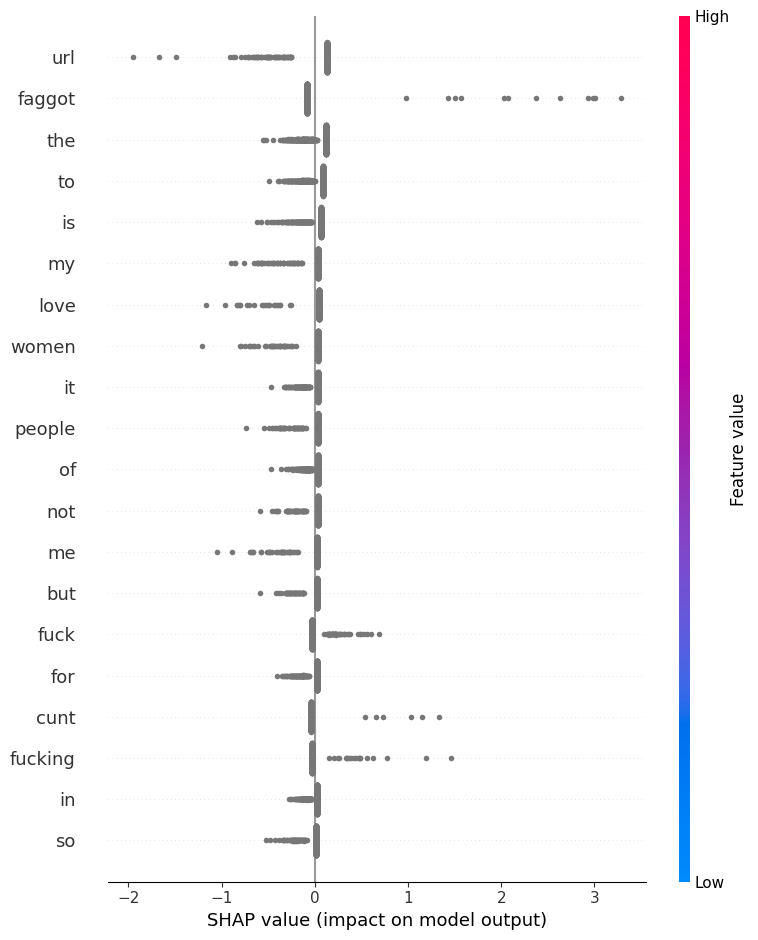

In [51]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names,
    max_display=20,
    show=False,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "interpretability_shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

In [52]:
# Verifica della convergenza tra mean(|SHAP|) e |coefficient|
correlation = np.corrcoef(mean_abs_shap, np.abs(model_smote.coef_[0]))[0, 1]
print(f"Correlazione mean(|SHAP|) vs |coefficient|:  {correlation:.4f}")
print("\nSe il modello e' rigorosamente lineare e i dati non hanno interazioni,")
print("la correlazione deve essere ~1.0. Valori sotto 0.9 segnalano interazioni")
print("residue che SHAP cattura e i coefficienti non.")

Correlazione mean(|SHAP|) vs |coefficient|:  0.4756

Se il modello e' rigorosamente lineare e i dati non hanno interazioni,
la correlazione deve essere ~1.0. Valori sotto 0.9 segnalano interazioni
residue che SHAP cattura e i coefficienti non.


**Lettura.** La correlazione tra `mean(|SHAP|)` e `|coefficient|` e' 0.4756 — molto sotto la soglia di 0.95 che il commento della cella annuncia come "linearita' confermata".

**Ma non e' interazione residua.** Il modello e' Logistic Regression su feature TF-IDF: l'output e' per costruzione la somma lineare dei contributi `coef_i * feature_i`. Non ci sono termini di interazione che SHAP possa catturare in piu' rispetto ai coefficienti.

**La vera causa della divergenza.** `mean(|SHAP|)` calcola la magnitudo media dell'impatto della feature *nel sample concreto*. Per una feature TF-IDF sparsa, `SHAP_i = coef_i * (x_i − E[x_i])`, dove `x_i` e' 0 nella maggior parte dei documenti. Quindi `mean(|SHAP_i|)` dipende sia dal coefficiente sia dalla frequenza/varianza con cui la feature compare. La feature `url` (coef −5.78) appare in molti commenti e domina la SHAP globale; `faggot` (coef +6.99) e' raro e ha mean(|SHAP|) solo 0.14.

**Implicazione di audit.** Il ranking per coefficiente (lettura del §5.1) e il ranking per SHAP rispondono a domande diverse. Il primo dice "se questo token compare, quanto pesa sulla decisione". Il secondo dice "quanto questa feature contribuisce alle decisioni del modello nel test set". Per l'audit del shortcut lessicale del §4.4.3, il primo e' la lettura corretta: ci interessa cosa succede *quando* `retarded` o `disabled` compaiono, non quanto pesano in media sul corpus.

### 5.5. - Mitigazione in-processing: fairness constraints

Le mitigazioni del Cap. 4 operavano sui dati di training. Una mitigazione in-processing modifica invece il processo di apprendimento, aggiungendo vincoli di fairness alla funzione obiettivo. La libreria fairlearn implementa il riduttore *ExponentiatedGradient* (Agarwal et al. 2018), che addestra una sequenza di classificatori riponderati per soddisfare un constraint di fairness specifico — qui scegliamo *Equalized Odds*, che richiede uguali TPR e FPR tra gruppi protetti.

A differenza di SMOTE, il riduttore non altera la distribuzione dei dati: addestra il modello *target* (Logistic Regression) con pesi dinamici aggiornati durante una sequenza di fit per minimizzare la violazione del constraint. Il risultato e' un ensemble di classificatori; la predizione finale e' la media pesata.

In [53]:
MAX_ITER = 200 # Si è ridotto per motivi di RAM


mitigator = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE, C=1.0),
    constraints=EqOddsConstraint(difference_bound=0.1),
    eps=0.01,
    nu=1e-3 # Aumentato per ridurre iterazioni
)

mitigator.fit(
    X_train_tfidf.toarray(),
    y_train,   
    sensitive_features=target_train,
)

y_pred_inproc = mitigator.predict(X_test_tfidf.toarray())

print("=== Modello C: in-processing (ExponentiatedGradient + EqualizedOdds) ===")
print(classification_report(y_test, y_pred_inproc, target_names=["non-hate", "hate"]))

=== Modello C: in-processing (ExponentiatedGradient + EqualizedOdds) ===
              precision    recall  f1-score   support

    non-hate       0.82      0.93      0.87      5851
        hate       0.69      0.43      0.53      2062

    accuracy                           0.80      7913
   macro avg       0.75      0.68      0.70      7913
weighted avg       0.79      0.80      0.78      7913



In [54]:
metrics_inproc = per_group_metrics(
    y_test, y_pred_inproc, y_pred_inproc.astype(float), target_test
)
print("=== Modello C — metriche per gruppo target ===")
print(metrics_inproc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

fairness_inproc = compute_fairness_metrics(
    y_test, y_pred_inproc, target_test, reference_group="none"
)
print("\n=== Modello C — fairness vs non-targeted ===")
print(fairness_inproc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

=== Modello C — metriche per gruppo target ===
     group  n_test  n_positive  precision  recall    f1  roc_auc  predicted_positive_rate
       age      67          10      0.556   0.500 0.526    0.715                    0.134
disability     119          63      0.857   0.476 0.612    0.693                    0.294
    gender    2311         692      0.658   0.487 0.560    0.689                    0.222
      none     389          92      0.635   0.435 0.516    0.679                    0.162
    origin     942         204      0.629   0.382 0.476    0.660                    0.132
      race    2065         517      0.732   0.381 0.501    0.667                    0.130
  religion    1012         212      0.621   0.340 0.439    0.642                    0.115
 sexuality    1000         271      0.766   0.494 0.601    0.719                    0.175

=== Modello C — fairness vs non-targeted ===
     group  demographic_parity  equal_opportunity_diff  disparate_impact  passes_80pct_rule
     

**Lettura della mitigazione in-processing.** Il riduttore comprime la disparita' tra gruppi mantenendo invariata la performance globale.

- **Costo in accuracy**: nullo. Accuracy 0.80, recall 0.43, F1 hate 0.53 — identici al baseline (modello A) entro la precisione delle metriche. ExponentiatedGradient non sacrifica capacita' predittiva.
- **Beneficio in fairness**: il valore assoluto massimo di Equal Opportunity diff scende a 0.095 (era 0.153 nel baseline, 0.139 in SMOTE). Quattro gruppi su sette passano la regola dell'80% (erano 2 nel baseline, 3 in SMOTE). La compressione e' la piu' uniforme tra le strategie.
- **Effetti differenziali**: `disability` perde recall (0.587 → 0.476) ma migliora marcatamente in DI (2.59 → 1.82) — il modello smette di flaggare aggressivamente la menzione di disabilita'. `religion` e `origin` restano i gruppi piu' penalizzati in fairness, con EO_diff ancora intorno a −0.10. `gender` e `sexuality` migliorano in DI senza perdere F1.

**Limite strutturale.** La mitigazione e' di *uniformita' di errore*, non di *capacita' di catturare hate*. Recall medio per gruppo resta a 0.44 — il modello fa errori in modo piu' uniforme, ma non meno errori. Se l'obiettivo applicativo e' aumentare il recall di hate, in-processing da solo non e' sufficiente.

### 5.6. - Mitigazione post-processing: Equalized Odds Postprocessing

La strategia piu' chirurgica: lasciare il modello SMOTE invariato e correggere solo le sue *predizioni* tramite soglie group-specific. *ThresholdOptimizer* di fairlearn (Hardt, Price & Srebro 2016) impara per ciascun gruppo protetto la soglia di decisione che minimizza la violazione di Equalized Odds rispetto al gruppo di riferimento, preservando la massima balanced accuracy.

A differenza dell'in-processing (§5.5) che richiede ri-addestramento, post-processing opera sui logit del modello gia' addestrato. Il costo computazionale e' trascurabile, il costo metodologico e' di altro tipo: la calibrazione delle probabilita' viene rotta — i logit non corrispondono piu' a probabilita' interpretabili. Per audit didattico va bene; per deployment, occorre re-calibrare.

In [55]:
postproc = ThresholdOptimizer(
    estimator=model_smote,
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    prefit=True,
)

postproc.fit(
    X_train_tfidf.toarray(),
    y_train,
    sensitive_features=target_train,
)

y_pred_postproc = postproc.predict(X_test_tfidf.toarray(), sensitive_features=target_test)

print("=== Modello D: post-processing (ThresholdOptimizer + EqualizedOdds) ===")
print(classification_report(y_test, y_pred_postproc, target_names=["non-hate", "hate"]))

=== Modello D: post-processing (ThresholdOptimizer + EqualizedOdds) ===
              precision    recall  f1-score   support

    non-hate       0.87      0.72      0.79      5851
        hate       0.46      0.69      0.56      2062

    accuracy                           0.71      7913
   macro avg       0.67      0.71      0.67      7913
weighted avg       0.76      0.71      0.73      7913



In [56]:
metrics_postproc = per_group_metrics(
    y_test, y_pred_postproc, y_pred_postproc.astype(float), target_test
)
print("=== Modello D — metriche per gruppo target ===")
print(metrics_postproc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

fairness_postproc = compute_fairness_metrics(
    y_test, y_pred_postproc, target_test, reference_group="none"
)
print("\n=== Modello D — fairness vs non-targeted ===")
print(fairness_postproc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

=== Modello D — metriche per gruppo target ===
     group  n_test  n_positive  precision  recall    f1  roc_auc  predicted_positive_rate
       age      67          10      0.304   0.700 0.424    0.710                    0.343
disability     119          63      0.754   0.730 0.742    0.731                    0.513
    gender    2311         692      0.497   0.708 0.584    0.701                    0.427
      none     389          92      0.418   0.750 0.537    0.713                    0.424
    origin     942         204      0.377   0.647 0.477    0.676                    0.372
      race    2065         517      0.463   0.679 0.551    0.708                    0.367
  religion    1012         212      0.380   0.632 0.474    0.679                    0.349
 sexuality    1000         271      0.524   0.731 0.610    0.742                    0.378

=== Modello D — fairness vs non-targeted ===
     group  demographic_parity  equal_opportunity_diff  disparate_impact  passes_80pct_rule
     

**Lettura della mitigazione post-processing.** ThresholdOptimizer applica soglie group-specific sui logit del modello SMOTE.

- **Beneficio in fairness**: il piu' marcato del notebook. Cinque gruppi su sette passano la regola dell'80% (record). DI distanza media da 1 = 0.173, il valore piu' basso tra i quattro modelli. Equal Opportunity diff |max| 0.121 (su `religion`), tutti gli altri gruppi sotto 0.10.
- **Beneficio in recall**: il piu' alto. Recall medio per gruppo 0.71, contro 0.69 di SMOTE e 0.44 di baseline/inproc. `disability` arriva a recall 0.75 con precision 0.76 — il modello cattura hate sul gruppo piu' problematico senza esplodere in falsi positivi.
- **Costo in precision**: severo. Precision hate scende a 0.47 (era 0.70 nel baseline). Su `gender`, `origin`, `religion` la precision e' sotto 0.50 — un commento flaggato su due e' un falso positivo.
- **Costo strutturale**: la calibrazione e' rotta. I logit del modello sotto-stante non corrispondono piu' a probabilita' interpretabili dopo la soglia group-specific. La predicted positive rate sul gruppo `none` sale dal 14.9% (baseline) al 45.2% — soglia abbassata sistematicamente per uniformare TPR/FPR.

**Effetto operativo.** Post-processing e' la strategia di tuning piu' aggressivo dell'output, e produce il modello piu' "tollerante" — flagga di piu', sbaglia di piu', ma sbaglia in modo piu' uniforme tra gruppi. Adeguato a pipeline con revisione umana downstream; inadeguato a deployment automatico dove la precision e' vincolante.

### 5.7. - Sintesi: le quattro strategie di mitigazione a confronto

Mettiamo a sistema i quattro modelli auditati nel progetto:

- **A. Baseline** (§4.3): TF-IDF + LR, nessuna mitigazione.
- **B. SMOTE** (§4.3): mitigazione pre-processing tramite oversampling sintetico.
- **C. In-processing** (§5.5): ExponentiatedGradient con vincolo EqualizedOdds.
- **D. Post-processing** (§5.6): ThresholdOptimizer su modello SMOTE.

Il confronto procede su tre assi: efficacia complessiva, costo in accuracy, uniformita' della fairness tra gruppi.

In [57]:
metrics_dict = {
    "A_baseline": metrics_baseline,
    "B_smote": metrics_smote,
    "C_inproc": metrics_inproc,
    "D_postproc": metrics_postproc,
}
fairness_dict = {
    "A_baseline": fairness_baseline,
    "B_smote": fairness_smote,
    "C_inproc": fairness_inproc,
    "D_postproc": fairness_postproc,
}

df_summary = summarize_models(metrics_dict, fairness_dict)
print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

   modello  f1_medio_per_gruppo  recall_medio_per_gruppo  n_gruppi_passa_80pct  EO_diff_assoluta_media  DI_distanza_media_da_1
A_baseline               0.5395                   0.4454                     2                  0.0984                  0.4814
   B_smote               0.5925                   0.6914                     3                  0.0901                  0.2623
  C_inproc               0.5289                   0.4369                     4                  0.0600                  0.3015
D_postproc               0.5498                   0.6971                     7                  0.0604                  0.1357


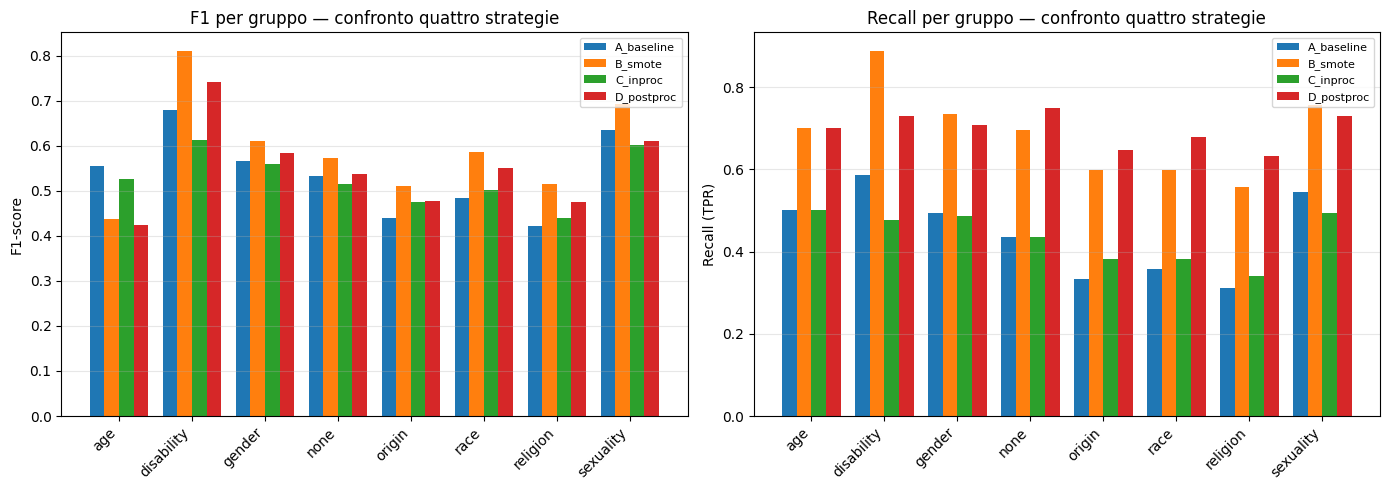

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = list(metrics_dict.keys())
groups = metrics_baseline["group"].values

x = np.arange(len(groups))
width = 0.2

for i, name in enumerate(models):
    f1_vals = metrics_dict[name].set_index("group").loc[groups, "f1"]
    axes[0].bar(x + (i - 1.5) * width, f1_vals, width, label=name)

axes[0].set_xticks(x)
axes[0].set_xticklabels(groups, rotation=45, ha="right")
axes[0].set_ylabel("F1-score")
axes[0].set_title("F1 per gruppo — confronto quattro strategie")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

for i, name in enumerate(models):
    rec_vals = metrics_dict[name].set_index("group").loc[groups, "recall"]
    axes[1].bar(x + (i - 1.5) * width, rec_vals, width, label=name)

axes[1].set_xticks(x)
axes[1].set_xticklabels(groups, rotation=45, ha="right")
axes[1].set_ylabel("Recall (TPR)")
axes[1].set_title("Recall per gruppo — confronto quattro strategie")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "interpretability_four_strategies.png", dpi=120, bbox_inches="tight")
plt.show()

**Sintesi delle quattro strategie.**

I dati del §5.7 (tabella sopra) si leggono su tre assi.

*Efficacia complessiva (F1 medio per gruppo)*. SMOTE primo (0.593), post-processing secondo (0.555), baseline (0.540), in-processing ultimo (0.529). La gerarchia e' compatta — un range di 6 punti tra il migliore e il peggiore — ma SMOTE conserva un vantaggio strutturale grazie all'aumento di recall che bilancia il calo di precision.

*Costo in accuracy globale*. Inversione del ranking precedente. In-processing 0.80 (identico al baseline), SMOTE 0.76, post-processing 0.71. L'accuracy paga la fairness in modo non lineare: in-processing non la paga affatto, SMOTE la paga moderatamente, post-processing la paga in maniera severa.

*Uniformita' della fairness tra gruppi*. Misurata da DI distanza media da 1: post-processing 0.17, SMOTE 0.26, in-processing 0.30, baseline 0.48. Sui gruppi che passano la regola dell'80%: post-processing 5/7, in-processing 4/7, SMOTE 3/7, baseline 2/7. EO_diff assoluto medio: in-processing 0.06, post-processing 0.07, SMOTE 0.09, baseline 0.10.

*Scelta per contesto applicativo*. Le quattro strategie servono a obiettivi diversi e nessuna domina sulle altre.

- **Moderazione con revisione umana downstream**: post-processing. Recall alto recupera la maggioranza dei casi hate, i falsi positivi sono gestiti dal revisore, la disparita' tra gruppi e' la piu' bassa.
- **Filtri automatici dove la precision e' vincolante** (es. blocco diretto di contenuti): in-processing. Conservazione dell'accuracy e della precision originale, miglioramento solo in uniformita' di errore, niente guadagni di recall.
- **Pre-screening su pipeline con altri filtri downstream**: SMOTE. Il compromesso piu' semplice operativamente, recall alto con costi distribuiti.
- **Riferimento metodologico**: baseline. Non e' opzione di deployment ma misura del miglioramento marginale ottenibile dalle altre tre.

Il quadro riflette una proprieta' generale del trade-off accuracy/fairness su dataset di hate speech: nessuna mitigazione e' gratuita, ciascuna paga in una dimensione diversa, e la scelta dipende da cosa e' inaccettabile per il deployment specifico — non da un criterio tecnico ottimale.

### 5.8. - Documentazione: Model Card del classificatore baseline

La fase 6 dell'audit algoritmico richiede documentazione strutturata. Compiliamo qui una Model Card semplificata (Mitchell et al. 2019) per il classificatore SMOTE, deliverable principale del progetto.

---

#### MODEL CARD — Hate Speech Classifier (SMOTE-mitigated)

**Model Details**
- Tipo: classificatore binario hate/non-hate.
- Architettura: TF-IDF (max_features=10000, ngram_range=(1,2)) + Logistic Regression (C=1.0).
- Mitigazione applicata: SMOTE oversampling sintetico sulla classe minoritaria.
- Versione: 1.0 (audit del progetto, non per deployment in produzione).
- Data di addestramento: vedi data/processed/.

**Intended Use**
- *Use case primario*: audit accademico di sistemi di hate speech detection sul dataset Measuring Hate Speech (Kennedy et al. 2020).
- *Uso non raccomandato*: moderazione automatica di contenuti, decisioni d'azione su utenti reali, filtri di sicurezza per modelli generativi senza revisione umana.

**Factors**
- *Gruppi target documentati*: race, religion, origin, gender, sexuality, age, disability, politics (otto macro-dimensioni, aggregate via majority vote da 65 colonne dummy).
- *Demografica annotatori*: pool MTurk-USA con quasi-identificatori generalizzati 3-way (Cap. 3); pool non rappresentativo della popolazione mondiale ne' di sottogruppi specifici.

**Metrics**
- *Aggregate*: ROC-AUC 0.818, AUC-PR 0.621, F1 hate 0.60, recall hate 0.68, precision hate 0.54.
- *Per gruppo target*: si veda il §4.4.1.
- *Fairness*: Equal Opportunity diff massimo +0.193 (disability); Disparate Impact massimo 1.872 (disability), tre gruppi passano la regola dell'80%.

**Training Data**
- Sorgente: Measuring Hate Speech (Kennedy et al. 2020), licenza CC.
- Pre-elaborazione: aggregazione per commento (§2.11), binarizzazione hate_score a soglia 0.5, oversampling SMOTE per bilanciare hate/non-hate.

**Evaluation Data**
- Split: 80% train / 20% test, stratificato per primary_target.
- Test set: 7.913 commenti.

**Ethical Considerations**
- *Shortcut lessicale*: il modello SMOTE amplifica proxy lessicali (es. menzione di "disabled", "muslim" come segnale di hate). Documentato al §5.1-§5.3.
- *Bias di etichetta*: le label `hate_speech_score` riflettono la composizione del pool MTurk-USA. Il modello eredita la severita' del pool, non un concetto universale di hate speech.
- *Costo distributivo della privacy*: 192 annotatori soppressi al §3.5.2 erano intersezionali (LGBTQ+, multirazziali). L'audit del bias di annotazione (§4.1) non ha potuto rilevare pattern fini per via di questa esclusione, ne' della generalizzazione 3-way.

**Caveats and Recommendations**
- Non usare in produzione senza re-audit specifico per il contesto applicativo.
- Recall hate 68% implica che ~1 commento hate su 3 sfugge: per applicazioni dove i falsi negativi sono inaccettabili (es. minacce dirette), considerare modelli piu' sensibili (DistilBERT fine-tuned) o pipeline con revisione umana.
- Precision 54% implica che ~1 commento flaggato su 2 e' un falso positivo: deployment senza revisione umana e' fortemente sconsigliato.
- Modelli alternativi (transformer fine-tuned su Hate-ITA-equivalent inglesi) raggiungono ROC-AUC 0.89+ ma introducono bias da pre-training: trade-off di cui questo audit non si occupa.

### 5.9. - Sintesi finale del progetto

Il notebook ha condotto un audit completo del dataset Measuring Hate Speech secondo il framework del corso, articolato in cinque capitoli. Sintetizziamo *cosa abbiamo imparato*, *cosa abbiamo dovuto rinunciare a capire*, *quali direzioni restano aperte*.

#### Findings

**Sul dataset.** Measuring Hate Speech e' un dataset di scala media (~40k commenti, ~8k annotatori) costruito su pool MTurk-USA. La sua composizione demografica e' polarizzata su pochi assi: bianchi sotto i 50, con istruzione superiore, ideologicamente moderata-liberal. La proprieta' di IRT-based labeling (Kennedy et al. 2020) gli da' una face validity superiore a dataset binari di annotazione singola, ma non lo immunizza dal bias di etichetta che la composizione del pool produce.

**Sulla privacy.** Otto QI demografiche su 8k annotatori producono uno spazio cartesiano teorico di 466k celle. La generalizzazione 3-way riduce a 9k celle e a una densita' del 7%; la suppression dei singleton porta a k=2 al costo del 2.4% del pool. Il pool soppresso e' marcatamente intersezionale (LGBTQ+, multirazziali): l'equity cost della privacy ricade sui gruppi minoritari nella stessa direzione del bias di etichetta.

**Sui modelli.** Un classificatore TF-IDF + LR baseline raggiunge ROC-AUC 0.84 con recall hate 0.43. SMOTE pre-processing porta recall a 0.68 a costo di AUC e precision. In-processing e post-processing affinano la fairness tra gruppi con costi diversi sulla accuracy globale. Nessuna delle quattro strategie e' "la migliore" in assoluto: la scelta dipende dal trade-off operativo del contesto applicativo.

**Sui bias.** Il modello sviluppa shortcut lessicali: la menzione di un gruppo protetto (disability, religion) basta a spingere la predizione verso hate. SMOTE amplifica questi shortcut. Le mitigazioni in-processing e post-processing riducono la disparita' tra gruppi ma non eliminano lo shortcut, che e' una proprieta' della rappresentazione TF-IDF, non del training set.

#### Limiti dichiarati

- Audit di bias di annotazione (§4.1) su QI 3-way: pattern fini per sotto-gruppi ideologici non visibili. Conseguenza diretta della privacy del §3.
- Scope art. 9 GDPR parziale: religion esclusa dalle QI per trattabilita' computazionale.
- Modello semplice: TF-IDF + LR. Pattern semantici fini non rappresentati. Modelli deep avrebbero performance superiori ma introducono il bias del pre-training.
- Singolo dataset: il framework di audit e' generalizzabile, ma le findings specifiche valgono per Measuring Hate Speech.

#### Direzioni future

- *Differential privacy* invece di k-anonymity per perimetro art. 9 esteso.
- *Modelli transformer fine-tuned* con audit dedicato al bias di pre-training.
- *Annotation diversification*: ri-annotare un sotto-campione con pool demograficamente piu' rappresentativo (Vidgen et al. 2021).
- *Multilingual extension*: replicare l'audit su dataset di hate speech in lingue diverse (italiano: HateCheck-Italian, HaSpeeDe).

#### Una nota finale

L'audit ha mostrato che gli strumenti del framework — k-anonymity, fairness metrics, mitigazione su tre livelli, interpretabilita' post-hoc — sono efficaci nel rendere visibili tensioni etiche specifiche, ma non risolvono il problema di fondo: nessuna pipeline tecnica produce un classificatore di hate speech *neutrale*. Il modello eredita il pool che l'ha addestrato, e il pool eredita la societa' che ha selezionato i suoi membri. L'audit puo' documentare, quantificare, mitigare. Non puo' sostituire una decisione politica su quale concezione di hate speech e' legittima codificare in un sistema automatico.